# HMM Model Recovery Project

## Recovering a Gaussian Hidden Markov Model From Synthetic Samples

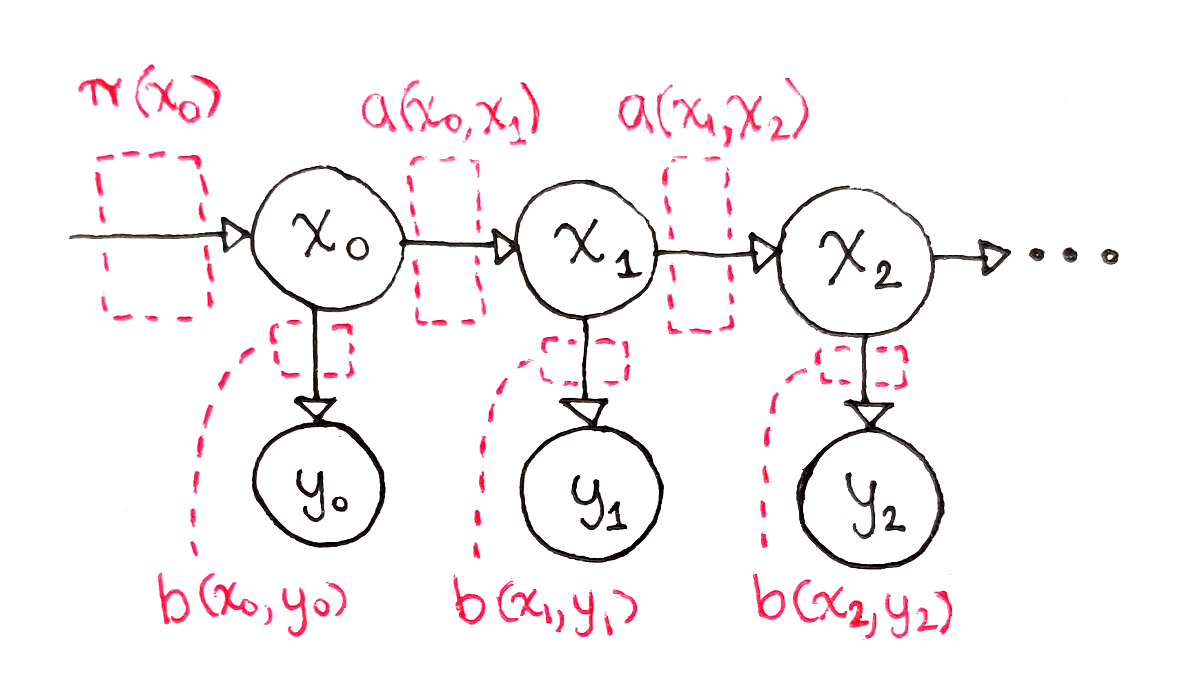

### Afeka College of Engineering  

**Students:**
- אביעד צפרי – 322281452  
- דוד אזימוב – 205697592  

**Course:**
Advanced Method in ML

**Date:**
Semester B, 2026

---


# Table of Contents

1. [Abstract](#1-abstract)
2. [Introduction](#2-introduction)

   1. [Motivation](#21-motivation)
   2. [Project Goal](#22-project-goal)
   3. [Research Questions](#23-research-questions)
3. [Theoretical Background](#3-theoretical-background)

   1. [Hidden Markov Model Definition](#31-hidden-markov-model-definition)
   2. [Gaussian Hidden Markov Model](#32-gaussian-hidden-markov-model)
   3. [The Three Classical HMM Problems](#33-the-three-classical-hmm-problems)
   4. [Forward Algorithm](#34-forward-algorithm)
   5. [Backward Algorithm](#35-backward-algorithm)
   6. [Posterior Probabilities](#36-posterior-probabilities)
   7. [Baum-Welch / EM Algorithm](#37-baum-welch--em-algorithm)
   8. [Viterbi Algorithm](#38-viterbi-algorithm)
   9. [Hidden-State Permutation Problem](#39-hidden-state-permutation-problem)
   10. [Model Complexity](#310-model-complexity)
4. [Original HMM From GitHub Repository](#4-original-hmm-from-github-repository)  
   1. [Repository Description](#41-repository-description)  
      1. [Imports and Configurations](#411-imports-and-configurations)  
      2. [Loading the Article Dataset](#412-loading-article-data)  
   2. [Original Model Parameters](#42-original-model-parameters)  
      1. [Data Preparation](#421-data-preparation)  
      2. [Gaussian HMM Wrapper](#422-gaussian-hmm-wrapper)  
      3. [Fitting the Original HMM](#423-fitting-the-original-hmm)  
      4. [Extracting and Freezing the Original HMM Parameters](#424-extracting-and-freezing-the-original-hmm-parameters)  
   3. [Interpretation of Hidden States](#43-interpretation-of-hidden-states)  
      1. [State Parameter Summary](#431-state-parameter-summary)  
      2. [Automatic State Interpretation](#432-automatic-state-interpretation)  
      3. [Log-Return Distribution by Hidden State](#433-log-return-distribution-by-state)  
      4. [Hidden-State Interpretation Summary](#434-hidden-state-interpretation-summary)  

5. [Synthetic Data Generation](#5-synthetic-data-generation)

   1. [Sampling Procedure](#51-sampling-procedure)
   2. [Generated Dataset](#52-generated-dataset)
   3. [Examples of Generated Sequences](#53-examples-of-generated-sequences)
6. [Training a New HMM](#6-training-a-new-hmm)

   1. [Learned Model Configuration](#61-learned-model-configuration)
   2. [Baum-Welch Training Procedure](#62-baum-welch-training-procedure)
   3. [Convergence Analysis](#63-convergence-analysis)
7. [State Alignment Before Comparison](#7-state-alignment-before-comparison)

   1. [Why Alignment Is Required](#71-why-alignment-is-required)
   2. [Alignment Method](#72-alignment-method)
   3. [Aligned Learned Parameters](#73-aligned-learned-parameters)
8. [Model Comparison Methodology](#8-model-comparison-methodology)

   1. [Parameter-Level Comparison](#81-parameter-level-comparison)
   2. [Likelihood-Based Comparison](#82-likelihood-based-comparison)
   3. [Generated Sequence Statistics Comparison](#83-generated-sequence-statistics-comparison)
   4. [Viterbi Path Comparison](#84-viterbi-path-comparison)
   5. [Computation Pipeline (Implementation)](#85-computation-pipeline-implementation)
   6. [Statistics and Decoding Evaluation (Implementation)](#86-statistics-and-decoding-evaluation-implementation)
   7. [Ablation and Summary Table Generation (Implementation)](#87-ablation-and-summary-table-generation-implementation)
9. [Experiments](#9-experiments)

   1. [Main Experiment](#91-main-experiment)
   2. [Effect of Number of Generated Samples](#92-effect-of-number-of-generated-samples)
   3. [Effect of Sequence Length](#93-effect-of-sequence-length)
   4. [Effect of Random Initialization](#94-effect-of-random-initialization)
   5. [Optional: Different Number of Hidden States](#95-optional-different-number-of-hidden-states)
10. [Results](#10-results)

    1. [Original Model Parameters](#101-original-model-parameters)
    2. [Learned Model Parameters](#102-learned-model-parameters)
    3. [Aligned Learned Model Parameters](#103-aligned-learned-model-parameters)
    4. [Convergence Results](#104-convergence-results)
    5. [Quantitative Comparison](#105-quantitative-comparison)
    6. [Generated Samples Comparison](#106-generated-samples-comparison)
11. [Discussion](#11-discussion)
12. [Limitations](#12-limitations)
13. [Conclusions](#13-conclusions)
14. [Future Work](#14-future-work)
15. [References](#16-references)

---

<a id="1-abstract"></a>

# 1. Abstract

This project investigates whether a Gaussian Hidden Markov Model (HMM) can be recovered from synthetic sequences generated by another Gaussian HMM.

We use an existing market-regime HMM as a frozen reference generator, sample synthetic sequences from it, and train a new HMM only from generated observations. We then compare the learned and original models using aligned parameter errors, likelihood on held-out sequences, generated-sample statistics, and Viterbi path agreement.

The learned model recovers the original structure with high fidelity in the two-state setting: emission-mean MAE is approximately $7.2\times10^{-5}$, test log-likelihood per step differs by approximately $-7.9\times10^{-4}$, and Viterbi agreement after alignment is approximately $99.23\%$.

These results support the effectiveness of Baum-Welch recovery under adequate synthetic sample size and sequence length.

---


<a id="2-introduction"></a>

# 2. Introduction

<a id="21-motivation"></a>

## 2.1 Motivation

Hidden Markov Models are probabilistic models used for sequential data where the observed behavior is assumed to be driven by hidden states.
They are useful in domains such as speech recognition, biological sequence analysis, financial time-series modeling, signal processing, and regime detection.

In financial markets, hidden states can represent latent market regimes, such as low-volatility growth periods and high-volatility crash periods.

Market regime detection is a suitable example for Hidden Markov Models because financial time series often behave differently during different periods. For example, the market may be in a stable low-volatility regime for a long time, and then switch to a high-volatility regime during a crisis or rapid decline. These regimes are not directly observed, but they affect the observed data, such as returns and volatility.

This structure fits the HMM assumption: the hidden state represents the current market regime, while the observed values are generated according to the current hidden state. The Markov assumption is also reasonable in this context, because market regimes tend to persist for some time, and the probability of moving to a new regime depends mainly on the current regime.

---


<a id="22-project-goal"></a>

## 2.2 Project Goal

The goal of this project is to test whether a new Gaussian HMM can learn the behavior of an original Gaussian HMM using only samples generated from the original model.

The project pipeline is:

$$
\lambda_{original}
\rightarrow
\text{generate synthetic samples}
\rightarrow
\text{train } \hat{\lambda}
\rightarrow
\text{align states}
\rightarrow
\text{compare models}
$$

where:

$$
\lambda_{original}
$$

is the original HMM, and:

$$
\hat{\lambda}
$$

is the learned HMM trained from generated data.

---

<a id="23-research-questions"></a>

## 2.3 Research Questions

This project investigates the following questions:

1. Can a Gaussian HMM trained with Baum-Welch learn a model that behaves similarly to the original HMM?
2. How close are the learned model parameters to the original model parameters after aligning the hidden states?
3. Do the original and learned models assign similar likelihoods to the same generated sequences?
4. How does the amount of generated data affect the quality of the learned HMM?


---

<a id="3-theoretical-background"></a>

# 3. Theoretical Background

<a id="31-hidden-markov-model-definition"></a>

## 3.1 Hidden Markov Model Definition

A Hidden Markov Model is a probabilistic model for sequential data.
At each time step $(t)$, the system has a hidden state:

$$
X_t
$$

and an observed output:

$$
Y_t
$$

The hidden state is not observed directly. Instead, each hidden state generates observations according to an emission distribution.

An HMM is usually defined by:

$$
\lambda = (\pi, A, B)
$$

where:

$\pi_i = P(X_1 = i)$ is the initial probability of hidden state $i$.

$A_{ij} = P(X_{t+1}=j \mid X_t=i)$ is the transition probability from state $i$ to state $j$.

$B$ represents the emission probabilities.

---

<a id="32-gaussian-hidden-markov-model"></a>

## 3.2 Gaussian Hidden Markov Model

In this project, the observations are continuous rather than discrete.
Therefore, we use a Gaussian HMM.

In a Gaussian HMM, each hidden state emits observations according to a Gaussian distribution:

$$
Y_t \mid X_t=i \sim \mathcal{N}(\mu_i, \Sigma_i)
$$

Therefore, the model parameters are:

$$
\lambda = (\pi, A, \mu, \Sigma)
$$

where:

* $\pi$ is the initial state distribution
* $A$ is the transition matrix
* $\mu_i$ is the mean vector of state $i$
* $\Sigma_i$ is the covariance matrix of state $i$

---


<a id="33-the-three-classical-hmm-problems"></a>

## 3.3 The Three Classical HMM Problems

There are three classical problems in HMMs.

### 3.3.1 Evaluation

Given an HMM $\lambda$ and an observation sequence $Y$, compute:

$$
P(Y \mid \lambda)
$$

This is solved using the Forward algorithm.

### 3.3.2 Decoding

Given an HMM $\lambda$ and an observation sequence $Y$, find the most likely hidden-state sequence:

$$
\arg\max_X P(X \mid Y, \lambda)
$$

This is solved using the Viterbi algorithm.

### 3.3.3 Learning

Given observation sequences, estimate the HMM parameters:

$$
\lambda = (\pi, A, \mu, \Sigma)
$$

This is solved using the Baum-Welch algorithm, which is a special case of Expectation-Maximization.

---

<a id="34-forward-algorithm"></a>

## 3.4 Forward Algorithm

The Forward algorithm computes the likelihood of an observation sequence efficiently using dynamic programming.

Define:

$$
\alpha_t(i) = P(y_1, y_2, \ldots, y_t, X_t=i \mid \lambda)
$$

Initialization:

$$
\alpha_1(i)=\pi_i b_i(y_1)
$$

Recursion:

$$
\alpha_{t+1}(j)=
\left[
\sum_i \alpha_t(i)A_{ij}
\right]
b_j(y_{t+1})
$$

Final likelihood:

$$
P(Y \mid \lambda)=\sum_i \alpha_T(i)
$$

In a Gaussian HMM, $b_i(y_t)$ is the Gaussian density of observation $y_t$ under state $i$.

---

<a id="35-backward-algorithm"></a>

## 3.5 Backward Algorithm

The Backward algorithm computes the probability of the remaining observations given the current hidden state.

Define:

$$
\beta_t(i)=P(y_{t+1}, y_{t+2}, \ldots, y_T \mid X_t=i,\lambda)
$$

Initialization:

$$
\beta_T(i)=1
$$

Recursion:

$$
\beta_t(i)=
\sum_j A_{ij}b_j(y_{t+1})\beta_{t+1}(j)
$$

---

<a id="36-posterior-probabilities"></a>

## 3.6 Posterior Probabilities

Baum-Welch uses posterior probabilities calculated from the Forward and Backward algorithms.

The state posterior is:

$$
\gamma_t(i)=P(X_t=i \mid Y,\lambda)
$$

It can be computed as:

$$
\gamma_t(i)=
\frac{
\alpha_t(i)\beta_t(i)
}{
P(Y \mid \lambda)
}
$$

The transition posterior is:

$$
\xi_t(i,j)=P(X_t=i,X_{t+1}=j \mid Y,\lambda)
$$

It can be computed as:

$$
\xi_t(i,j)=
\frac{
\alpha_t(i)A_{ij}b_j(y_{t+1})\beta_{t+1}(j)
}{
P(Y \mid \lambda)
}
$$

---

<a id="37-baum-welch--em-algorithm"></a>

## 3.7 Baum-Welch / EM Algorithm

Baum-Welch is an Expectation-Maximization algorithm for estimating HMM parameters from observations.

### E-step

Using the current model parameters, compute:

* Forward probabilities ($\alpha$)
* Backward probabilities ($\beta$)
* State posteriors ($\gamma$)
* Transition posteriors ($\xi$)

### M-step

Update the model parameters using the expected hidden-state counts.

Initial probabilities:

$$
\pi_i^{new} = \gamma_1(i)
$$

Transition probabilities:

$$
A_{ij}^{new}=
\frac{
\sum_{t=1}^{T-1}\xi_t(i,j)
}{
\sum_{t=1}^{T-1}\gamma_t(i)
}
$$

For Gaussian emissions, the mean and covariance of each state are updated using posterior-weighted observations.

Mean update:

$$
\mu_i^{new}
=
\frac{
\sum_{t=1}^{T}\gamma_t(i)y_t
}{
\sum_{t=1}^{T}\gamma_t(i)
}
$$

Covariance update:

$$
\Sigma_i^{new}
=
\frac{
\sum_{t=1}^{T}\gamma_t(i)(y_t-\mu_i)(y_t-\mu_i)^T
}{
\sum_{t=1}^{T}\gamma_t(i)
}
$$

Baum-Welch increases the likelihood at each iteration, but it may converge to a local maximum.

---

<a id="38-viterbi-algorithm"></a>

## 3.8 Viterbi Algorithm

The Viterbi algorithm finds the most likely sequence of hidden states for a given observation sequence.

In this project, Viterbi decoding is useful because it allows us to compare how the original and learned models explain the same observation sequence.

We can compare:

* decoded state paths
* state occupancy frequencies
* transition counts between decoded states
* agreement between the original-model path and learned-model path

---

<a id="39-hidden-state-permutation-problem"></a>

## 3.9 Hidden-State Permutation Problem

Hidden-state labels in an HMM are arbitrary.

For example, state 0 in the original model may correspond to state 1 in the learned model.
Therefore, direct parameter comparison may be misleading.

For example, comparing:

$$
A_{original}
\quad \text{with} \quad
A_{learned}
$$

may give a large error even if the learned model is actually correct but has swapped state labels.

To solve this, we align the learned states with the original states before comparison.

If $P$ is a permutation matrix, then the aligned transition matrix is:

$$
A_{learned}^{aligned} = P A_{learned} P^T
$$

The aligned Gaussian means are:

$$
\mu_{learned}^{aligned} = P\mu_{learned}
$$

The aligned covariance matrices are reordered according to the same state permutation.

Only after this alignment step do we compare the original and learned parameters.

---

<a id="310-model-complexity"></a>

## 3.10 Model Complexity

Let:

* $K$ be the number of hidden states
* $T$ be the sequence length

The time complexity of the Forward algorithm is:

$$
O(TK^2)
$$

The time complexity of the Backward algorithm is:

$$
O(TK^2)
$$

The time complexity of the Viterbi algorithm is:

$$
O(TK^2)
$$

The memory complexity is usually:

$$
O(TK)
$$

---

<a id="4-original-hmm-from-github-repository"></a>

# 4. Original HMM From GitHub Repository

<a id="41-repository-description"></a>

## 4.1 Repository Description

The original HMM is based on the GitHub repository `LSEG-API-Samples/Article.RD.Python.MarketRegimeDetectionUsingStatisticalAndMLBasedApproaches` [2].

The repository demonstrates market regime detection using statistical and machine-learning-based approaches. In the original project, the goal is to identify normal market periods and crash or rapid-decline periods in S&P 500 market data. Several methods are used in the repository, including Gaussian HMM, Gaussian Mixture Model, and clustering methods.

In this project, we focus only on the Gaussian HMM component. We use the HMM structure from the repository as the basis for our original model. After fitting or extracting this model, we freeze its parameters and treat it as the original generative HMM.

The original repository contains a Jupyter notebook named `Market regime detection.ipynb` and an HTML export named `Market regime detection.html`. In the relevant HMM part of the notebook, a `GaussianHMM` model is initialized, trained on market log-return data, and then used to predict hidden market states.

<a id="411-imports-and-configurations"></a>

### 4.1.1 Imports and Configurations

In [31]:
# Installations in our venv
import sys

print("Current Python executable:")
print(sys.executable)

!{sys.executable} -m pip install --upgrade pip setuptools wheel
#lseg-data
!{sys.executable} -m pip install numpy pandas matplotlib scipy scikit-learn hmmlearn plotly 

Current Python executable:
c:\Users\aviad\OneDrive\Documents\GIT\DeepLearning\.venv\Scripts\python.exe


In [32]:
### Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import math

from hmmlearn.hmm import GaussianHMM
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")

RANDOM_SEED = 100
np.random.seed(RANDOM_SEED)


def train_best_hmm(
    train_obs,
    train_lengths,
    test_obs=None,
    test_lengths=None,
    n_states=2,
    n_restarts=10,
    n_iter=1000,
    tol=1e-4,
    base_seed=42,
    verbose=True,
):
    """Train GaussianHMM with multiple random restarts.

    Selects the model with the highest training log-likelihood.

    Returns:
        best_model : fitted GaussianHMM
        results_df : DataFrame with restart, seed, train_ll, test_ll, n_iter
    """
    best_model, best_ll = None, -np.inf
    rows = []

    for r in range(n_restarts):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type="full",
            n_iter=n_iter,
            tol=tol,
            random_state=base_seed + r,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(train_obs, train_lengths)

        train_ll = model.score(train_obs, train_lengths)
        test_ll  = (
            model.score(test_obs, test_lengths)
            if test_obs is not None else float("nan")
        )

        rows.append({
            "restart": r,
            "seed":    base_seed + r,
            "train_ll": train_ll,
            "test_ll":  test_ll,
            "n_iter":   model.monitor_.iter,
        })

        if verbose:
            test_str = f", Test LL={test_ll:10.2f}" if test_obs is not None else ""
            print(
                f"  Restart {r + 1:2d}: Train LL={train_ll:10.2f}{test_str},"
                f" Iterations={model.monitor_.iter}"
            )

        if train_ll > best_ll:
            best_ll, best_model = train_ll, model

    return best_model, pd.DataFrame(rows)


<a id="412-loading-article-data"></a>

### 4.1.2 Loading the Article Dataset

Since access to the live LSEG/Refinitiv API depends on a configured desktop session, we use the price series extracted from the article notebook output.

This keeps the same article dataset while making the project notebook reproducible without requiring a live API session.

In [33]:
# Inspecting the dataset
trading_instrument = "ESc1"

prices = pd.read_csv("ESc1_article_prices_from_notebook.csv", parse_dates=["Date"])
prices = prices.set_index("Date")
prices.columns.name = trading_instrument

# Basic validation of the loaded article dataset
print("Dataset shape:", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Columns:", prices.columns.tolist())
prices.head()

Dataset shape: (6398, 1)
Date range: 1997-09-09 00:00:00 to 2023-02-01 00:00:00
Columns: ['ESc1']


ESc1,ESc1
Date,
1997-09-09,934.25
1997-09-10,917.50
1997-09-11,908.75
1997-09-12,924.50
1997-09-15,921.00


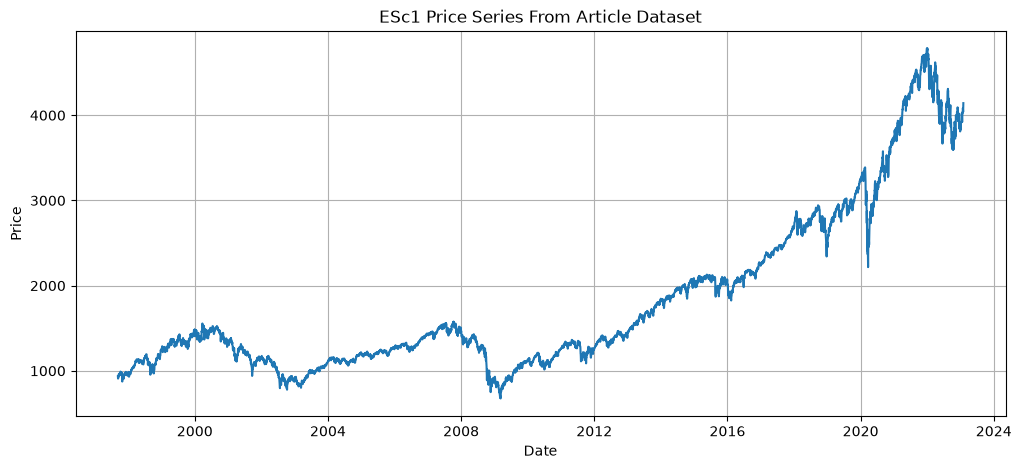

In [34]:
# Plotting the original dataset
plt.figure(figsize=(12, 5))
plt.plot(prices.index, prices[trading_instrument])
plt.title("ESc1 Price Series From Article Dataset")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

<a id="42-original-model-parameters"></a>

## 4.2 Original Model Parameters

Before fitting the Gaussian HMM, we prepare the market price series in the same general way as the original repository.

The price series is smoothed using a moving average, and then log returns are computed from the moving-average series. The Gaussian HMM is trained on the log-return sequence, not directly on the raw price series.

<a id="421-data-preparation"></a>

### 4.2.1 Data Preparation

The raw price series is transformed before fitting the HMM, following the article approach.

In [35]:
# Helper function from the article
def prepare_data_for_model_input(prices, instrument, ma):
    """Prepare market data as input for the Gaussian HMM.

    Input:
        prices:     DataFrame containing the price column.
        instrument: Name of the price column (string).
        ma:         Moving-average window size (int).

    Output:
        prepared_prices : enhanced DataFrame with MA and log-return columns.
        prices_array    : NumPy array of log returns shaped (-1, 1) for hmmlearn.
    """
    prepared_prices = prices.copy()

    prepared_prices[f"{instrument}_ma"] = (
        prepared_prices[instrument].rolling(ma).mean()
    )
    prepared_prices[f"{instrument}_log_return"] = np.log(
        prepared_prices[f"{instrument}_ma"]
        / prepared_prices[f"{instrument}_ma"].shift(1)
    )
    prepared_prices.dropna(inplace=True)

    prices_array = (
        prepared_prices[f"{instrument}_log_return"].values.reshape(-1, 1)
    )
    return prepared_prices, prices_array


In [36]:
# Applying data preparation
prices_prepared, prices_array = prepare_data_for_model_input(
    prices, trading_instrument, ma=7
)

print("Prepared data shape:", prices_prepared.shape)
print("HMM input array shape:", prices_array.shape)

prices_prepared.head()


Prepared data shape: (6391, 3)
HMM input array shape: (6391, 1)


ESc1,ESc1,ESc1_ma,ESc1_log_return
Date,,,
1997-09-18,948.25,930.000000,0.002153
1997-09-19,960.25,936.107143,0.006545
1997-09-22,965.50,944.214286,0.008623
1997-09-23,961.75,949.535714,0.005620
1997-09-24,953.00,954.107143,0.004803


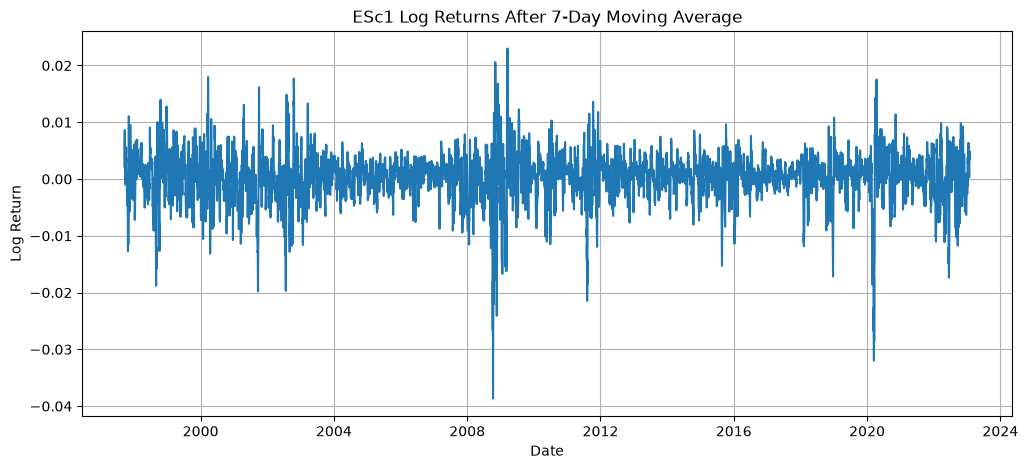

In [37]:
# Log return visualization
plt.figure(figsize=(12, 5))
plt.plot(prices_prepared.index, prices_prepared[f"{trading_instrument}_log_return"])
plt.title("ESc1 Log Returns After 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

<a id="422-gaussian-hmm-wrapper"></a>

### 4.2.2 Gaussian HMM Wrapper

The following class is adapted from the repository structure.

For this project, we keep only the Gaussian HMM functionality, because our goal is to fit an original HMM, freeze its parameters, generate synthetic samples from it, train a new HMM, and compare the learned model with the original model.

In [38]:
# Helper class from the article
class RegimeDetection:
    """
    Wrapper class for fitting a Gaussian HMM.

    In this project, we use only the HMM part of the original repository.
    """

    def get_regimes_hmm(self, input_data, params):
        hmm_model = self.initialise_model(GaussianHMM(), params).fit(input_data)
        return hmm_model

    def initialise_model(self, model, params):
        for parameter, value in params.items():
            setattr(model, parameter, value)
        return model

<a id="423-fitting-original-hmm"></a>

### 4.2.3 Fitting the Original HMM

We now fit a two-state Gaussian HMM to the prepared log-return data.

This fitted model represents the original HMM in our project.

In [39]:
regime_detection = RegimeDetection()

original_hmm_params = {
    "n_components": 2,
    "covariance_type": "full",
    "random_state": RANDOM_SEED,
    "n_iter": 1000,
    "tol": 1e-4
}

original_hmm = regime_detection.get_regimes_hmm(
    input_data=prices_array,
    params=original_hmm_params
)

original_states = original_hmm.predict(prices_array)

print("Original HMM training completed.")
print("Number of hidden states:", original_hmm.n_components)

Original HMM training completed.
Number of hidden states: 2


<a id="424-extracting-and-freezing-parameters"></a>

### 4.2.4 Extracting and Freezing the Original HMM Parameters

After fitting the model, we extract its learned parameters:

$$
\lambda_{original} = (\pi_{original}, A_{original}, \mu_{original}, \Sigma_{original})
$$

These parameters are frozen and used as the reference model for generating synthetic samples.

In [40]:
lambda_original = {
    "startprob": original_hmm.startprob_.copy(),
    "transmat": original_hmm.transmat_.copy(),
    "means": original_hmm.means_.copy(),
    "covars": original_hmm.covars_.copy()
}

print("Original initial state probabilities:")
print(lambda_original["startprob"])

print("\nOriginal transition matrix:")
print(lambda_original["transmat"])

print("\nOriginal Gaussian means:")
print(lambda_original["means"])

print("\nOriginal Gaussian covariance matrices:")
print(lambda_original["covars"])

Original initial state probabilities:
[1.14397097e-06 9.99998856e-01]

Original transition matrix:
[[0.90938926 0.09061074]
 [0.01615328 0.98384672]]

Original Gaussian means:
[[-0.00345795]
 [ 0.00088881]]

Original Gaussian covariance matrices:
[[[6.93514872e-05]]

 [[9.56669996e-06]]]


In [41]:
# Hidden state summary
unique_states, state_counts = np.unique(original_states, return_counts=True)

state_summary = pd.DataFrame({
    "State": unique_states,
    "Count": state_counts,
    "Percentage": state_counts / len(original_states)
})

state_summary

,State,Count,Percentage
0,0,891,0.139415
1,1,5500,0.860585


From this point forward, the trained model is treated as the original HMM:

$$
\lambda_{original} = (\pi_{original}, A_{original}, \mu_{original}, \Sigma_{original})
$$

where:

* $\pi_{original}$ is the initial state distribution.
* $A_{original}$ is the transition matrix.
* $\mu_{original}$ contains the Gaussian means.
* $\Sigma_{original}$ contains the Gaussian covariance matrices.

These parameters will be used to generate synthetic sequences. A new HMM will then be trained on those generated sequences and compared against this frozen original model.

---

<a id="43-interpretation-of-hidden-states"></a>

## 4.3 Interpretation of Hidden States

In the market-regime setting, hidden states may represent different latent market conditions.

For example:

* one state may represent a stable or low-volatility regime
* another state may represent a volatile or crash regime

The exact interpretation depends on the learned means, variances, and transition behavior.

<a id="431-state-parameter-summary"></a>

### 4.3.1 State Parameter Summary

To interpret the hidden states, we examine the Gaussian emission parameters of each state.

For each hidden state, we look at:

* the mean log return
* the variance of log returns
* the standard deviation of log returns
* the percentage of observations assigned to the state

A state with lower variance usually represents a more stable market regime, while a state with higher variance usually represents a more volatile market regime.

In [42]:
n_states = original_hmm.n_components

state_means = lambda_original["means"].reshape(n_states)
state_variances = lambda_original["covars"].reshape(n_states, -1)[:, 0]
state_std = np.sqrt(state_variances)

state_counts = (
    pd.Series(original_states)
    .value_counts()
    .sort_index()
    .reindex(range(n_states), fill_value=0)
)

state_parameter_summary = pd.DataFrame({
    "State": range(n_states),
    "Mean Log Return": state_means,
    "Variance": state_variances,
    "Std. Dev.": state_std,
    "Annualized Std. Dev.": state_std * np.sqrt(252),
    "Count": state_counts.values,
    "Percentage": state_counts.values / len(original_states)
})

state_parameter_summary

,State,Mean Log Return,Variance,Std. Dev.,Annualized Std. Dev.,Count,Percentage
0,0,-0.003458,0.000069,0.008328,0.132199,891,0.139415
1,1,0.000889,0.000010,0.003093,0.049100,5500,0.860585


<a id="432-automatic-state-interpretation"></a>

### 4.3.2 Automatic State Interpretation

Since the hidden-state labels are arbitrary, we interpret the states according to their statistical behavior.

The state with the lower standard deviation is interpreted as the more stable regime.  
The state with the higher standard deviation is interpreted as the more volatile regime.

In [43]:
state_parameter_summary = state_parameter_summary.copy()

volatility_rank = state_parameter_summary["Std. Dev."].rank(method="first")

state_parameter_summary["Interpretation"] = np.where(
    volatility_rank == volatility_rank.min(),
    "Stable / low-volatility regime",
    "Volatile / high-volatility regime"
)

state_parameter_summary

,State,Mean Log Return,Variance,Std. Dev.,Annualized Std. Dev.,Count,Percentage,Interpretation
0,0,-0.003458,0.000069,0.008328,0.132199,891,0.139415,Volatile / high-volatility regime
1,1,0.000889,0.000010,0.003093,0.049100,5500,0.860585,Stable / low-volatility regime


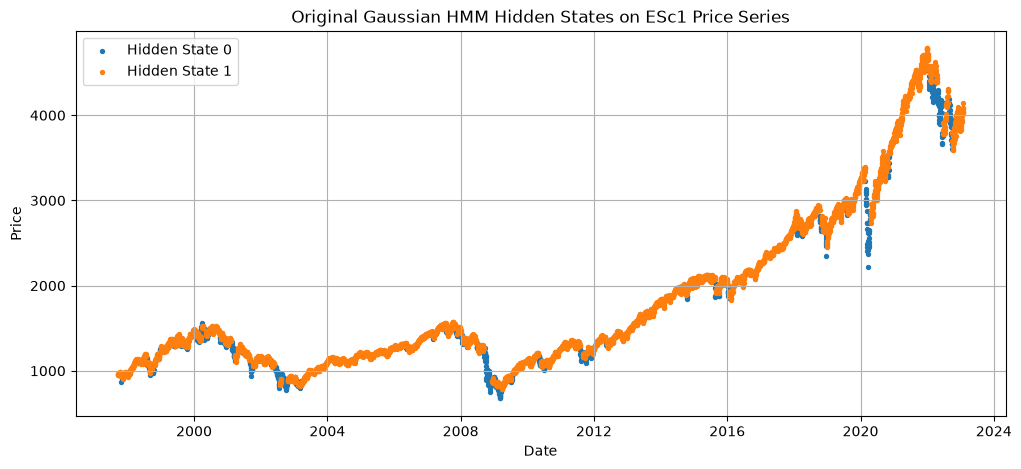

In [44]:
# Hidden state visualization
plt.figure(figsize=(12, 5))

for state in np.unique(original_states):
    mask = original_states == state
    plt.scatter(
        prices_prepared.index[mask],
        prices_prepared[trading_instrument][mask],
        s=8,
        label=f"Hidden State {state}"
    )

plt.title("Original Gaussian HMM Hidden States on ESc1 Price Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

<a id="433-log-return-distribution-by-state"></a>

### 4.3.3 Log-Return Distribution by Hidden State

We now compare the distribution of log returns assigned to each hidden state.

If the HMM learned meaningful regimes, the states should show different statistical behavior, especially in their variance.

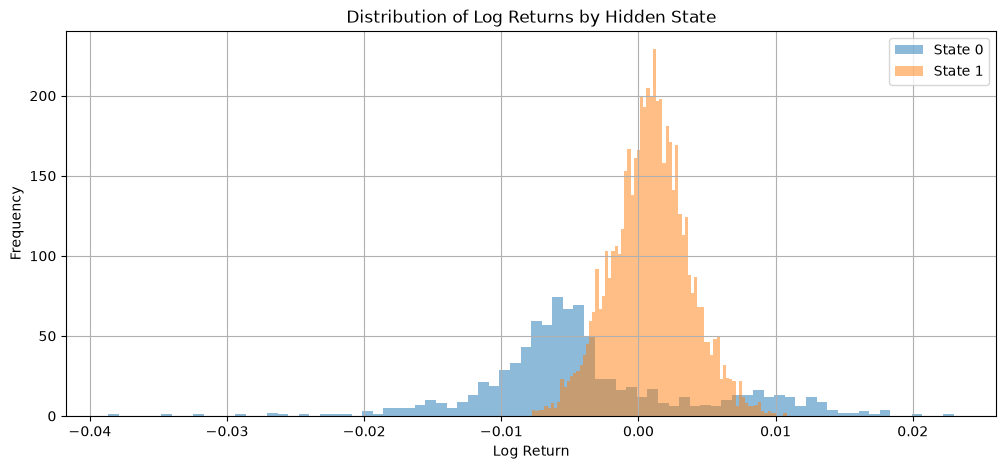

In [45]:
plt.figure(figsize=(12, 5))

log_return_column = f"{trading_instrument}_log_return"

for state in range(n_states):
    mask = original_states == state
    plt.hist(
        prices_prepared.loc[mask, log_return_column],
        bins=80,
        alpha=0.5,
        label=f"State {state}"
    )

plt.title("Distribution of Log Returns by Hidden State")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

<a id="434-hidden-state-interpretation-summary"></a>

### 4.3.4 Hidden-State Interpretation Summary

Based on the learned Gaussian emission parameters, the original HMM separates the market data into regimes with different volatility levels.

The state with the smaller standard deviation represents a more stable regime, while the state with the larger standard deviation represents a more volatile regime. This matches the market-regime interpretation of HMMs, where hidden states represent latent market conditions that are not directly observed from the raw price series.

These interpreted states will be used only to understand the original HMM. In the next sections, the model parameters themselves are frozen and used to generate synthetic samples.

---

<a id="5-synthetic-data-generation"></a>

# 5. Synthetic Data Generation

<a id="51-sampling-procedure"></a>

## 5.1 Sampling Procedure

We generate synthetic observation sequences from the frozen original model $\lambda_{original}$ using `hmmlearn` sampling.

The sampling process is:

1. sample an initial hidden state according to $\pi_{original}$
2. sample an observation from the Gaussian distribution of that state
3. sample the next hidden state according to $A_{original}$
4. repeat until the desired sequence length is reached

Implementation details used in this notebook:

* sampling function: `original_hmm.sample(...)`
* reproducibility: fixed random seed
* output saved per sequence: observations and true hidden states

The generated observations are used as training data for the new HMM.

In [46]:
# Synthetic sampling configuration
N_SYNTHETIC_SEQUENCES = 80
SYNTHETIC_SEQUENCE_LENGTH = 252
SYNTHETIC_RANDOM_SEED = 101
TRAIN_SEQUENCE_RATIO = 0.80

rng = np.random.RandomState(SYNTHETIC_RANDOM_SEED)

synthetic_sequences = []
synthetic_hidden_state_sequences = []

for _ in range(N_SYNTHETIC_SEQUENCES):
    sequence_obs, sequence_states = original_hmm.sample(
        n_samples=SYNTHETIC_SEQUENCE_LENGTH,
        random_state=rng
    )
    synthetic_sequences.append(sequence_obs)
    synthetic_hidden_state_sequences.append(sequence_states)

synthetic_observations = np.vstack(synthetic_sequences)
synthetic_hidden_states = np.concatenate(synthetic_hidden_state_sequences)
synthetic_lengths = [SYNTHETIC_SEQUENCE_LENGTH] * N_SYNTHETIC_SEQUENCES

n_train_sequences = int(N_SYNTHETIC_SEQUENCES * TRAIN_SEQUENCE_RATIO)
train_sequences = synthetic_sequences[:n_train_sequences]
test_sequences = synthetic_sequences[n_train_sequences:]

train_hidden_state_sequences = synthetic_hidden_state_sequences[:n_train_sequences]
test_hidden_state_sequences = synthetic_hidden_state_sequences[n_train_sequences:]

synthetic_train_observations = np.vstack(train_sequences)
synthetic_test_observations = np.vstack(test_sequences)

synthetic_train_hidden_states = np.concatenate(train_hidden_state_sequences)
synthetic_test_hidden_states = np.concatenate(test_hidden_state_sequences)

synthetic_train_lengths = [SYNTHETIC_SEQUENCE_LENGTH] * n_train_sequences
synthetic_test_lengths = [SYNTHETIC_SEQUENCE_LENGTH] * (N_SYNTHETIC_SEQUENCES - n_train_sequences)

print("Synthetic sampling completed.")
print("All generated observations shape:", synthetic_observations.shape)
print("Train observations shape:", synthetic_train_observations.shape)
print("Test observations shape:", synthetic_test_observations.shape)

Synthetic sampling completed.
All generated observations shape: (20160, 1)
Train observations shape: (16128, 1)
Test observations shape: (4032, 1)


<a id="52-generated-dataset"></a>

## 5.2 Generated Dataset

The generated dataset contains:

* number of sequences: **80**
* sequence length: **252**
* total number of observations: **20,160**
* train/test split: **64 / 16 sequences (80% / 20%)**
* random seed: **101**

The new HMM is trained only on the generated observations.

The true hidden states are saved for evaluation and visualization, but they are not used during training.

---

In [47]:
# Dataset summary table for Section 5.2
generated_dataset_summary = pd.DataFrame({
    "Metric": [
        "Number of sequences",
        "Sequence length",
        "Total observations",
        "Train sequences",
        "Test sequences",
        "Train observations",
        "Test observations",
        "Random seed"
    ],
    "Value": [
        N_SYNTHETIC_SEQUENCES,
        SYNTHETIC_SEQUENCE_LENGTH,
        synthetic_observations.shape[0],
        n_train_sequences,
        N_SYNTHETIC_SEQUENCES - n_train_sequences,
        synthetic_train_observations.shape[0],
        synthetic_test_observations.shape[0],
        SYNTHETIC_RANDOM_SEED
    ]
})

generated_dataset_summary

,Metric,Value
0,Number of sequences,80
1,Sequence length,252
2,Total observations,20160
3,Train sequences,64
4,Test sequences,16
5,Train observations,16128
6,Test observations,4032
7,Random seed,101


<a id="53-examples-of-generated-sequences"></a>

## 5.3 Examples of Generated Sequences

This section demonstrates the synthetic observation sequences generated from the original HMM model. We show examples of generated observation time series, their corresponding hidden state sequences, and the distribution of observations.

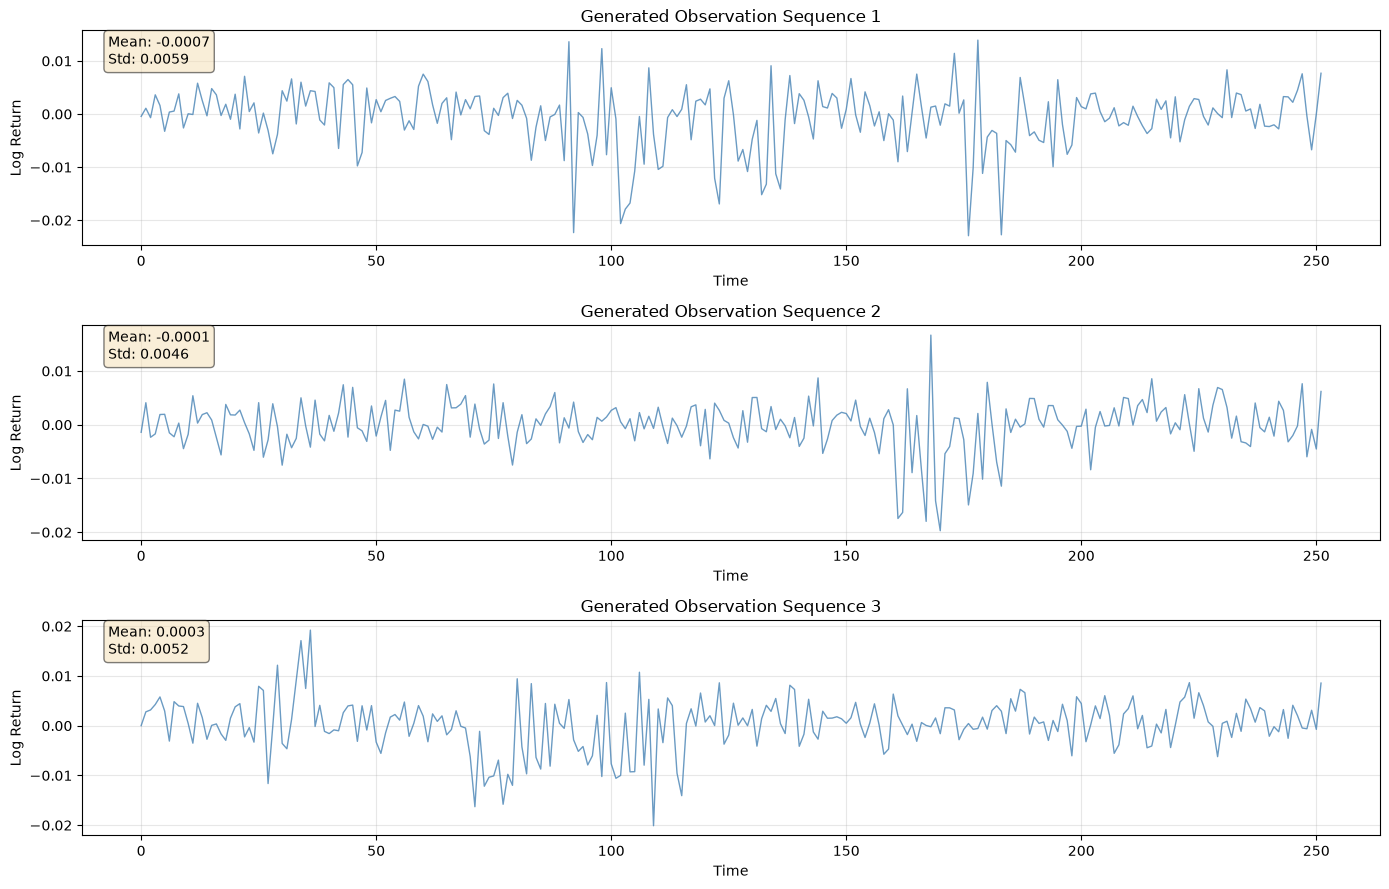

Displayed 3 example generated observation sequences


In [48]:
# Example: Plot several generated observation sequences
num_examples = 3
fig, axes = plt.subplots(num_examples, 1, figsize=(14, 3 * num_examples))

for idx in range(num_examples):
    start_idx = idx * SYNTHETIC_SEQUENCE_LENGTH
    end_idx   = (idx + 1) * SYNTHETIC_SEQUENCE_LENGTH
    seq_data  = synthetic_observations[start_idx:end_idx]

    axes[idx].plot(seq_data, linewidth=1, color="steelblue", alpha=0.8)
    axes[idx].set_title(f"Generated Observation Sequence {idx + 1}")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Log Return")
    axes[idx].grid(True, alpha=0.3)

    mean_val = np.mean(seq_data)
    std_val  = np.std(seq_data)
    axes[idx].text(
        0.02, 0.98, f"Mean: {mean_val:.4f}\nStd: {std_val:.4f}",
        transform=axes[idx].transAxes, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

plt.tight_layout()
plt.show()
print(f"Displayed {num_examples} example generated observation sequences")


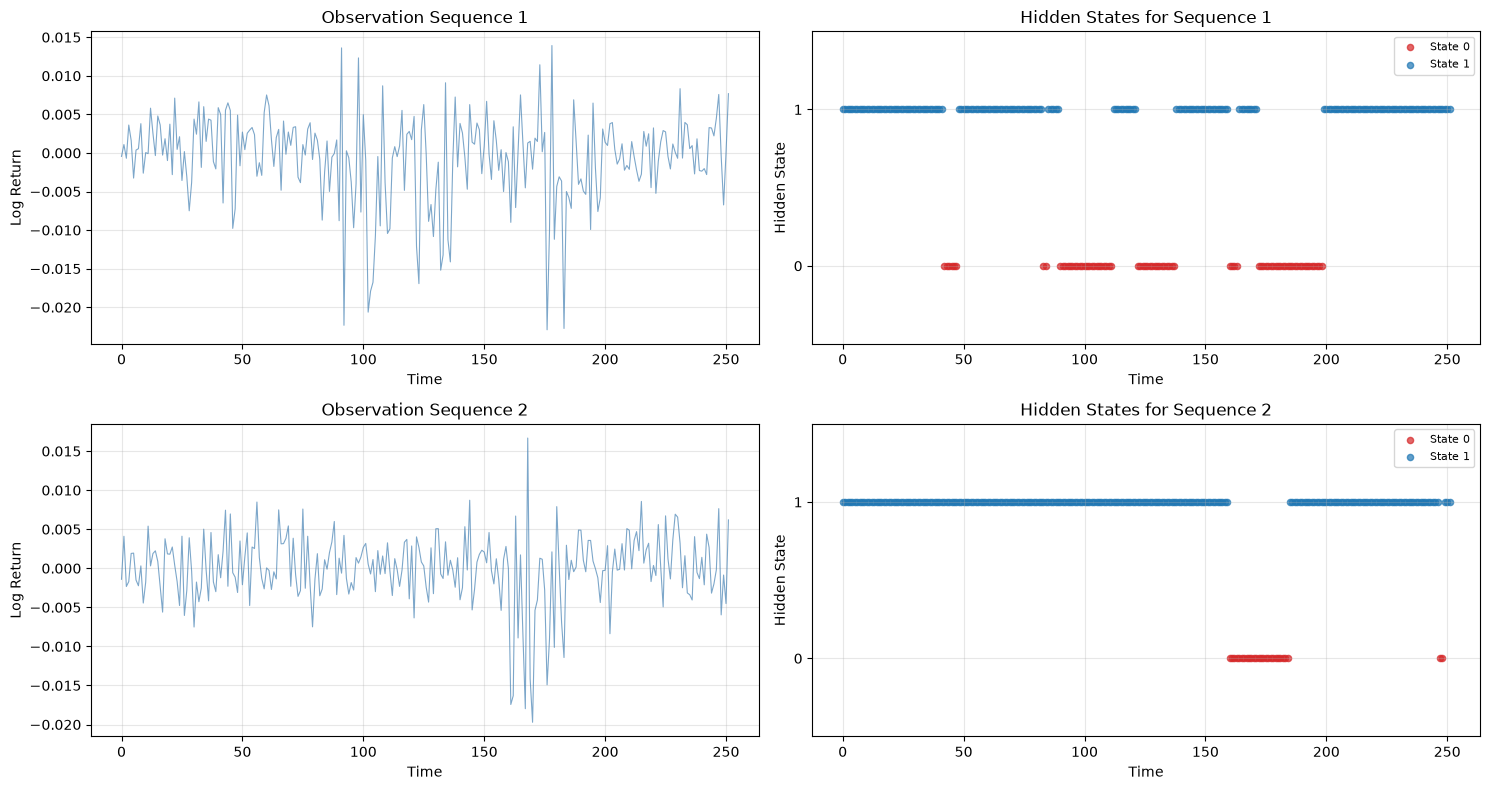

Displayed 2 example sequences with their hidden states


In [49]:
# Example: Plot generated observation sequences with their hidden states
num_examples = 2
state_clrs   = ["tab:red", "tab:blue", "tab:green", "tab:orange"]
fig, axes = plt.subplots(num_examples, 2, figsize=(15, 4 * num_examples))

for idx in range(num_examples):
    start_idx  = idx * SYNTHETIC_SEQUENCE_LENGTH
    end_idx    = (idx + 1) * SYNTHETIC_SEQUENCE_LENGTH
    seq_obs    = synthetic_observations[start_idx:end_idx]
    seq_states = synthetic_hidden_states[start_idx:end_idx]

    axes[idx, 0].plot(seq_obs, linewidth=0.8, color="steelblue", alpha=0.7)
    axes[idx, 0].set_title(f"Observation Sequence {idx + 1}")
    axes[idx, 0].set_xlabel("Time")
    axes[idx, 0].set_ylabel("Log Return")
    axes[idx, 0].grid(True, alpha=0.3)

    for state in range(original_hmm.n_components):
        mask = seq_states == state
        axes[idx, 1].scatter(
            np.where(mask)[0], seq_states[mask],
            label=f"State {state}",
            color=state_clrs[state % len(state_clrs)],
            s=20, alpha=0.7,
        )

    axes[idx, 1].set_title(f"Hidden States for Sequence {idx + 1}")
    axes[idx, 1].set_xlabel("Time")
    axes[idx, 1].set_ylabel("Hidden State")
    axes[idx, 1].set_ylim(-0.5, original_hmm.n_components - 0.5)
    axes[idx, 1].set_yticks(range(original_hmm.n_components))
    axes[idx, 1].legend(loc="upper right", fontsize=8)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Displayed {num_examples} example sequences with their hidden states")


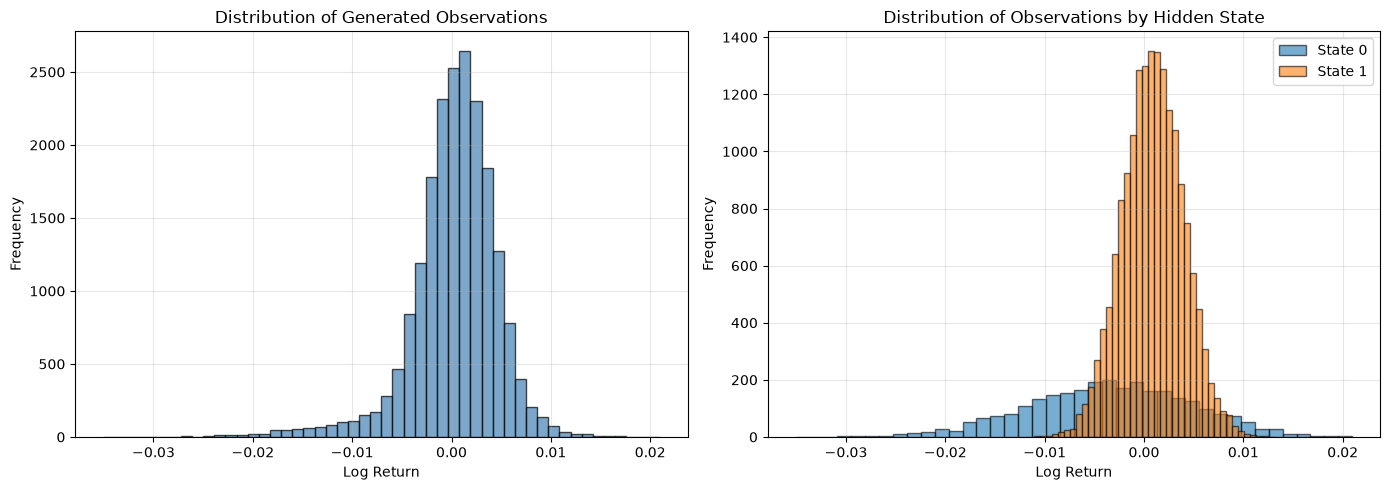


=== Statistical Summary of Generated Observations ===
Overall mean: 0.000257
Overall std:  0.004449
Overall min:  -0.035075
Overall max:  0.020951

=== Statistics by Hidden State ===

State 0: (14.0% of observations)
  Mean: -0.003453
  Std:  0.008235
  Min:  -0.035075
  Max:  0.020951

State 1: (86.0% of observations)
  Mean: 0.000859
  Std:  0.003067
  Min:  -0.011103
  Max:  0.013070


In [50]:
# Statistical summary and distribution of generated observations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(synthetic_observations, bins=50, color="steelblue", alpha=0.7,
             edgecolor="black")
axes[0].set_title("Distribution of Generated Observations")
axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

for state in range(original_hmm.n_components):
    mask = synthetic_hidden_states == state
    axes[1].hist(synthetic_observations[mask], bins=40, alpha=0.6,
                 label=f"State {state}", edgecolor="black")

axes[1].set_title("Distribution of Observations by Hidden State")
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Statistical Summary of Generated Observations ===")
print(f"Overall mean: {np.mean(synthetic_observations):.6f}")
print(f"Overall std:  {np.std(synthetic_observations):.6f}")
print(f"Overall min:  {np.min(synthetic_observations):.6f}")
print(f"Overall max:  {np.max(synthetic_observations):.6f}")

print("\n=== Statistics by Hidden State ===")
for state in range(original_hmm.n_components):
    mask      = synthetic_hidden_states == state
    state_obs = synthetic_observations[mask]
    freq      = np.sum(mask) / len(synthetic_hidden_states)
    print(f"\nState {state}: ({freq * 100:.1f}% of observations)")
    print(f"  Mean: {np.mean(state_obs):.6f}")
    print(f"  Std:  {np.std(state_obs):.6f}")
    print(f"  Min:  {np.min(state_obs):.6f}")
    print(f"  Max:  {np.max(state_obs):.6f}")


In [51]:
# Summary table of generated state characteristics
rows_list = []
for state in range(original_hmm.n_components):
    mask      = synthetic_hidden_states == state
    state_obs = synthetic_observations[mask]
    freq      = np.sum(mask) / len(synthetic_hidden_states)
    rows_list.append({
        "State":         state,
        "Count":         int(np.sum(mask)),
        "Frequency (%)": f"{freq * 100:.2f}%",
        "Mean":          f"{np.mean(state_obs):.6f}",
        "Std":           f"{np.std(state_obs):.6f}",
        "Min":           f"{np.min(state_obs):.6f}",
        "Max":           f"{np.max(state_obs):.6f}",
        "Original Mean": f"{lambda_original['means'][state, 0]:.6f}",
        "Original Std":  f"{np.sqrt(lambda_original['covars'][state, 0, 0]):.6f}",
    })

generated_state_summary_df = pd.DataFrame(rows_list)
print("=== Generated vs. Original State Parameters ===")
print(generated_state_summary_df.to_string(index=False))

print("\n=== Generation Quality Metrics ===")
for state in range(original_hmm.n_components):
    mask      = synthetic_hidden_states == state
    state_obs = synthetic_observations[mask]
    mean_err  = abs(np.mean(state_obs) - lambda_original["means"][state, 0])
    std_err   = abs(np.std(state_obs)  - np.sqrt(lambda_original["covars"][state, 0, 0]))
    print(f"\nState {state}:")
    print(f"  Mean error: {mean_err:.6f}")
    print(f"  Std error:  {std_err:.6f}")


=== Generated vs. Original State Parameters ===
 State  Count Frequency (%)      Mean      Std       Min      Max Original Mean Original Std
     0   2816        13.97% -0.003453 0.008235 -0.035075 0.020951     -0.003458     0.008328
     1  17344        86.03%  0.000859 0.003067 -0.011103 0.013070      0.000889     0.003093

=== Generation Quality Metrics ===

State 0:
  Mean error: 0.000005
  Std error:  0.000093

State 1:
  Mean error: 0.000029
  Std error:  0.000026


<a id="6-training-a-new-hmm"></a>

# 6. Training a New HMM

<a id="61-learned-model-configuration"></a>

## 6.1 Learned Model Configuration

The learned model is also a Gaussian HMM.

$$
\hat{\lambda} = (\hat{\pi}, \hat{A}, \hat{\mu}, \hat{\Sigma})
$$

Configuration:

* number of hidden states: **2**
* covariance type: **full**
* number of EM iterations: **1000**
* convergence threshold: **1e-4**
* random seed: **42**
* number of random restarts: **10**

---

<a id="62-baum-welch-training-procedure"></a>

## 6.2 Baum-Welch Training Procedure

The learned HMM is trained on synthetic observation sequences generated from the original HMM.

Training uses the `GaussianHMM` implementation in `hmmlearn`. The procedure is:

1. Initialize a Gaussian HMM with the configuration from Section 6.1.
2. Fit the model on concatenated training sequences with explicit `lengths` metadata.
3. Run EM (Baum-Welch):
   - E-step: forward-backward inference for expected sufficient statistics.
   - M-step: update $\pi$, $A$, $\mu$, and $\Sigma$ to increase likelihood.
4. Repeat until either:
   - log-likelihood improvement is below `tol=1e-4`, or
   - the maximum number of iterations (`n_iter=1000`) is reached.
5. Repeat training with multiple random restarts and keep the highest-likelihood solution.

This setup reduces sensitivity to poor initializations and improves robustness of model recovery.


In [52]:
# Training configuration for the learned HMM
learned_hmm_config = {
    "n_components": 2,
    "covariance_type": "full",
    "n_iter": 1000,
    "tol": 1e-4,
    "base_seed": 42,
    "n_restarts": 10,
}

print("=" * 60)
print("TRAINING NEW HMM USING BAUM-WELCH ALGORITHM")
print("=" * 60)
print("\nConfiguration:")
for k, v in learned_hmm_config.items():
    print(f"  {k}: {v}")

print(
    f"\nTraining {learned_hmm_config['n_restarts']} models "
    "with different random initializations..."
)
print("-" * 60)

best_model, restart_results_df = train_best_hmm(
    train_obs=synthetic_train_observations,
    train_lengths=synthetic_train_lengths,
    test_obs=synthetic_test_observations,
    test_lengths=synthetic_test_lengths,
    n_states=learned_hmm_config["n_components"],
    n_restarts=learned_hmm_config["n_restarts"],
    n_iter=learned_hmm_config["n_iter"],
    tol=learned_hmm_config["tol"],
    base_seed=learned_hmm_config["base_seed"],
    verbose=True,
)

best_restart_idx = int(restart_results_df["train_ll"].idxmax())

print("-" * 60)
print(f"\nBest model found at restart {best_restart_idx + 1}")
print(f"Best training log-likelihood: {restart_results_df['train_ll'].max():.2f}")
print(f"Best test log-likelihood:     {restart_results_df.loc[best_restart_idx, 'test_ll']:.2f}")

print("\n" + "=" * 60)
print("RESTART RESULTS SUMMARY")
print("=" * 60)
print(restart_results_df.to_string(index=False))
print(
    f"\nMean train LL : {restart_results_df['train_ll'].mean():.2f}"
    f"   Std: {restart_results_df['train_ll'].std():.4f}"
)
print(
    f"Mean test  LL : {restart_results_df['test_ll'].mean():.2f}"
    f"   Std: {restart_results_df['test_ll'].std():.4f}"
)

# Extract parameters from the best learned model
lambda_learned = {
    "startprob": best_model.startprob_.copy(),
    "transmat":  best_model.transmat_.copy(),
    "means":     best_model.means_.copy(),
    "covars":    best_model.covars_.copy(),
}

print("\n" + "=" * 60)
print("BEST LEARNED HMM PARAMETERS (Before Alignment)")
print("=" * 60)
print("\nInitial state probabilities:", lambda_learned["startprob"])
print("\nTransition matrix:\n",         lambda_learned["transmat"])
print("\nGaussian means:\n",             lambda_learned["means"])
print("\nGaussian covariance matrices:\n", lambda_learned["covars"])

print("\n" + "=" * 60)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 60)


TRAINING NEW HMM USING BAUM-WELCH ALGORITHM

Configuration:
  n_components: 2
  covariance_type: full
  n_iter: 1000
  tol: 0.0001
  base_seed: 42
  n_restarts: 10

Training 10 models with different random initializations...
------------------------------------------------------------


Model is not converging.  Current: 67396.31083290967 is not greater than 67396.45152809151. Delta is -0.14069518183532637


  Restart  1: Train LL=  67396.18, Test LL=  16706.42, Iterations=18


Model is not converging.  Current: 67396.11315512552 is not greater than 67396.13173892161. Delta is -0.018583796088933013


  Restart  2: Train LL=  67396.09, Test LL=  16706.33, Iterations=11


...

  Restart  8: Train LL=  67396.20, Test LL=  16706.43, Iterations=24


Model is not converging.  Current: 67396.40994738387 is not greater than 67396.55518817199. Delta is -0.14524078811518848


  Restart  9: Train LL=  67396.24, Test LL=  16706.47, Iterations=26


Model is not converging.  Current: 67396.35158266079 is not greater than 67396.39107194307. Delta is -0.039489282280555926


  Restart 10: Train LL=  67396.22, Test LL=  16706.46, Iterations=14
------------------------------------------------------------

Best model found at restart 9
Best training log-likelihood: 67396.24
Best test log-likelihood:     16706.47

RESTART RESULTS SUMMARY
 restart  seed     train_ll      test_ll  n_iter
       0    42 67396.183743 16706.424320      18
       1    43 67396.088258 16706.334991      11
       2    44 67396.209980 16706.449546      12
       3    45 67396.192107 16706.426731      39
       4    46 67396.132930 16706.379753      12
       5    47 67396.226791 16706.464344      26
       6    48 67396.167868 16706.403400      30
       7    49 67396.198367 16706.431559      24
       8    50 67396.236136 16706.472581      26
       9    51 67396.215601 16706.463679      14

Mean train LL : 67396.19   Std: 0.0454
Mean test  LL : 16706.43   Std: 0.0429

BEST LEARNED HMM PARAMETERS (Before Alignment)

Initial state probabilities: [9.99999927e-01 7.33400140e-08]

Transit

---

<a id="63-convergence-analysis"></a>

## 6.3 Convergence Analysis

Convergence is assessed by tracking training log-likelihood across EM iterations for the selected best restart.

What we verify:

1. **Monotone improvement trend** in log-likelihood (allowing small numerical fluctuations near termination).
2. **Practical convergence** before the hard iteration cap.
3. **Cross-restart consistency** of final likelihood values.

In this notebook run, the best model converged well before the maximum iteration budget, and the final train log-likelihood values across restarts are tightly clustered (standard deviation approximately $0.045$). This indicates stable optimization behavior for the current two-state synthetic setting.


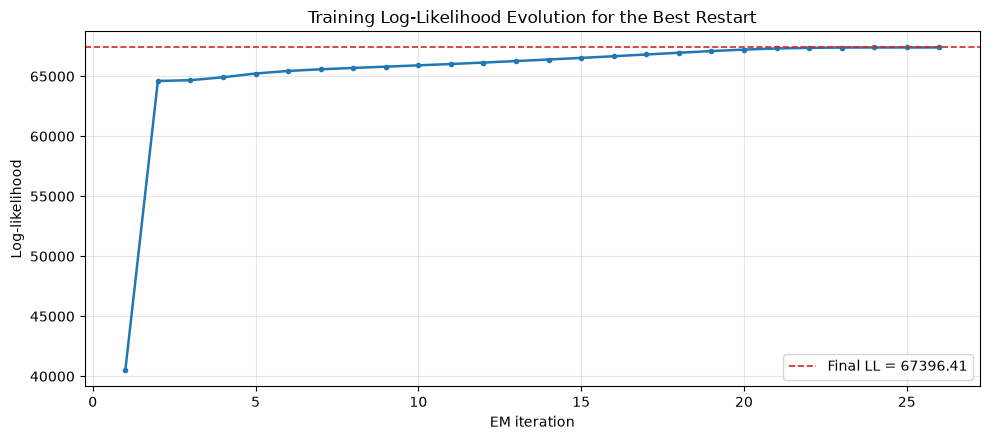


CONVERGENCE SUMMARY ACROSS RANDOM RESTARTS
 restart     train_ll      test_ll  n_iter
       0 67396.183743 16706.424320      18
       1 67396.088258 16706.334991      11
       2 67396.209980 16706.449546      12
       3 67396.192107 16706.426731      39
       4 67396.132930 16706.379753      12
       5 67396.226791 16706.464344      26
       6 67396.167868 16706.403400      30
       7 67396.198367 16706.431559      24
       8 67396.236136 16706.472581      26
       9 67396.215601 16706.463679      14

Mean final train log-likelihood across restarts: 67396.19
Std. dev. of final train log-likelihood across restarts: 0.05
Best restart: 9 with train LL=67396.24

Conclusion: convergence appears fairly stable across restarts, since the final log-likelihood values are similar.
The best restart converged before reaching the maximum number of EM iterations.


In [53]:

if hasattr(best_model, "monitor_") and hasattr(best_model.monitor_, "history"):
    ll_history = list(best_model.monitor_.history)
    iterations = np.arange(1, len(ll_history) + 1)

    plt.figure(figsize=(10, 4.5))
    plt.plot(iterations, ll_history, color="tab:blue", linewidth=1.8, marker="o", markersize=3)
    plt.axhline(ll_history[-1], color="tab:red", linestyle="--", linewidth=1.2,
                label=f"Final LL = {ll_history[-1]:.2f}")
    plt.xlabel("EM iteration")
    plt.ylabel("Log-likelihood")
    plt.title("Training Log-Likelihood Evolution for the Best Restart")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history was recorded for the selected model.")

if "restart_results_df" in globals():
    print("\n" + "=" * 60)
    print("CONVERGENCE SUMMARY ACROSS RANDOM RESTARTS")
    print("=" * 60)
    print(restart_results_df[["restart", "train_ll", "test_ll", "n_iter"]].to_string(index=False))

    train_std = restart_results_df["train_ll"].std()
    final_ll_mean = restart_results_df["train_ll"].mean()
    best_restart = restart_results_df.loc[restart_results_df["train_ll"].idxmax()]

    print(f"\nMean final train log-likelihood across restarts: {final_ll_mean:.2f}")
    print(f"Std. dev. of final train log-likelihood across restarts: {train_std:.2f}")
    print(f"Best restart: {int(best_restart['restart']) + 1} with train LL={best_restart['train_ll']:.2f}")

    if train_std < 20:
        print("\nConclusion: convergence appears fairly stable across restarts, since the final log-likelihood values are similar.")
    else:
        print("\nConclusion: convergence is less stable across restarts, since the final log-likelihood values vary noticeably.")

    if best_restart["n_iter"] < 1000:
        print("The best restart converged before reaching the maximum number of EM iterations.")
    else:
        print("The best restart reached the maximum number of EM iterations, so convergence may not have been fully achieved.")


<a id="7-state-alignment-before-comparison"></a>

# 7. State Alignment Before Comparison

<a id="71-why-alignment-is-required"></a>

## 7.1 Why Alignment Is Required

Before comparing the original and learned HMMs, we must solve the hidden-state permutation problem.

In an HMM, the hidden states are only defined up to a permutation. This means that the learned model may assign the same underlying regime to a different state index than the original model.

For example, the original model may label one regime as state 0, while the learned model may label that same regime as state 1. As a result, state 0 in the original model is not guaranteed to correspond to state 0 in the learned model.

If we compare parameters directly without aligning the states, we may incorrectly compare the wrong pairs of states. This can make the means, covariances, transition probabilities, and initial probabilities appear more different than they really are.

Therefore, alignment is necessary before any parameter-level comparison is meaningful.

---

<a id="72-alignment-method"></a>

## 7.2 Alignment Method

We align the learned states to the original states using a state-similarity criterion.

Possible criteria include:

* distance between Gaussian means
* distance between covariance matrices
* likelihood similarity
* Viterbi path agreement

In this project, we use Gaussian mean distance with linear sum assignment.

The idea is to compare each learned state with each original state using the absolute difference between their Gaussian means.
We align states by minimizing the distance between Gaussian means using the Hungarian algorithm (linear sum assignment).

The cost matrix is defined as:

$$
cost(i,j)=\left|\mu_i^{\text{original}}-\mu_j^{\text{learned}}\right|
$$

We then solve a one-to-one matching problem to find the permutation that minimizes the total cost. This is done with the Hungarian algorithm, which is implemented through the linear sum assignment routine.

This choice is appropriate because the state means are directly related to the underlying regime behavior, and aligning the states by their means makes the comparison of the learned and original HMMs more meaningful. It also ensures that the learned parameters are reordered consistently before any parameter-level comparison is performed.

---

<a id="73-aligned-learned-parameters"></a>

## 7.3 Aligned Learned Parameters

After estimating the optimal state permutation with linear sum assignment, we reorder all learned parameters into the original-model state order:

$$
\hat{\pi}^{aligned},\; \hat{A}^{aligned},\; \hat{\mu}^{aligned},\; \hat{\Sigma}^{aligned}
$$

In this run, the learned-state mapping is:

* learned state 0 $\rightarrow$ original state 1
* learned state 1 $\rightarrow$ original state 0

This confirms that a non-trivial permutation occurred, so alignment is not optional. All downstream parameter, likelihood, and Viterbi comparisons use only the aligned representation.

---

Alignment cost matrix:
[[4.30350848e-03 4.32576965e-05]
 [1.01634516e-04 4.44840069e-03]]

State mapping (learned -> original):
  learned state 0 -> original state 1
  learned state 1 -> original state 0

Aligned start probabilities:
[7.33400140e-08 9.99999927e-01]

Aligned transition matrix:
[[0.91719914 0.08280086]
 [0.01318294 0.98681706]]

Aligned Gaussian means:
[[-0.00355959]
 [ 0.00084556]]

Aligned Gaussian covariance matrices:
[[[7.25150542e-05]]

 [[1.01590336e-05]]]


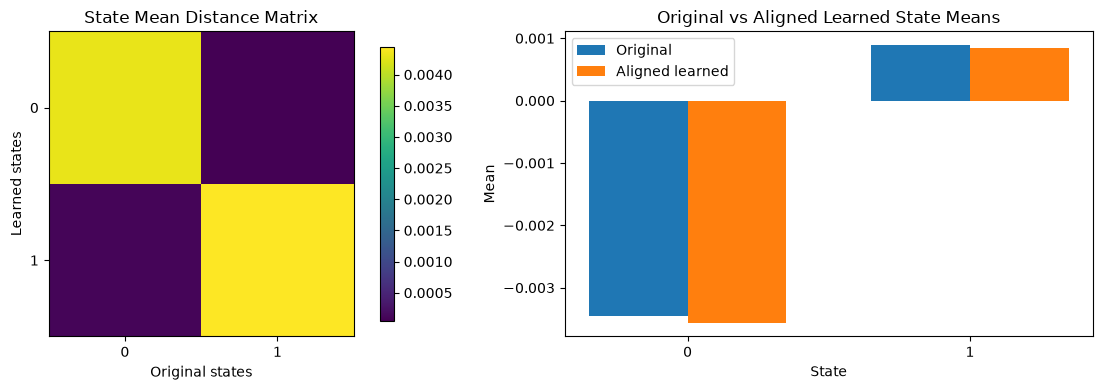

In [54]:
# Align learned HMM states to the original frozen model using Gaussian mean distance
if "lambda_original" in globals() and "lambda_learned" in globals():
    # Extract the HMM parameters that need to be compared after alignment
    original_means = np.asarray(lambda_original["means"])
    learned_means = np.asarray(lambda_learned["means"])

    # Ensure the means are shaped as [n_states, n_features]
    if original_means.ndim == 1:
        original_means = original_means[:, None]
    if learned_means.ndim == 1:
        learned_means = learned_means[:, None]

    # Flatten the mean vectors so each state is represented by a single feature vector
    original_means_flat = original_means.reshape(original_means.shape[0], -1)
    learned_means_flat = learned_means.reshape(learned_means.shape[0], -1)

    # Build a cost matrix where each entry is the distance between one learned state mean
    # and one original state mean. Smaller values mean a better match.
    cost_matrix = np.linalg.norm(
        learned_means_flat[:, None, :] - original_means_flat[None, :, :],
        axis=2
    )

    # Solve the assignment problem to find the best one-to-one state matching
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # Create a permutation array that reorders the learned states to match the original ones
    state_order = np.empty(len(row_ind), dtype=int)
    state_order[col_ind] = row_ind

    # Reorder the learned parameters so that they are aligned with the original model
    aligned_startprob = lambda_learned["startprob"][state_order]
    aligned_transmat = lambda_learned["transmat"][np.ix_(state_order, state_order)]
    aligned_means = lambda_learned["means"][state_order]
    aligned_covars = lambda_learned["covars"][state_order]

    # Print the alignment result for inspection
    print("Alignment cost matrix:")
    print(cost_matrix)
    print("\nState mapping (learned -> original):")
    for learned_state, original_state in zip(row_ind, col_ind):
        print(f"  learned state {learned_state} -> original state {original_state}")

    print("\nAligned start probabilities:")
    print(aligned_startprob)

    print("\nAligned transition matrix:")
    print(aligned_transmat)

    print("\nAligned Gaussian means:")
    print(aligned_means)

    print("\nAligned Gaussian covariance matrices:")
    print(aligned_covars)

    # Visualize the alignment quality in a way that is easier to interpret
    original_means_display = original_means_flat[:, 0]
    aligned_means_display = learned_means_flat[state_order, 0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left plot: distance matrix between original and learned state means
    im = axes[0].imshow(cost_matrix, cmap="viridis")
    axes[0].set_title("State Mean Distance Matrix")
    axes[0].set_xlabel("Original states")
    axes[0].set_ylabel("Learned states")
    axes[0].set_xticks(range(cost_matrix.shape[1]))
    axes[0].set_yticks(range(cost_matrix.shape[0]))
    fig.colorbar(im, ax=axes[0], shrink=0.9)

    # Right plot: original vs aligned learned state means
    x = np.arange(len(original_means_display))
    width = 0.35
    axes[1].bar(x - width / 2, original_means_display, width, label="Original", color="tab:blue")
    axes[1].bar(x + width / 2, aligned_means_display, width, label="Aligned learned", color="tab:orange")
    axes[1].set_title("Original vs Aligned Learned State Means")
    axes[1].set_xlabel("State")
    axes[1].set_ylabel("Mean")
    axes[1].set_xticks(x)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("The original and learned HMM parameter dictionaries are not available yet.")

<a id="8-model-comparison-methodology"></a>

# 8. Model Comparison Methodology

<a id="81-parameter-level-comparison"></a>

## 8.1 Parameter-Level Comparison

We compare the original parameters to the aligned learned parameters:

$$
\pi_{original} \; \text{vs} \; \hat{\pi}^{aligned},\quad
A_{original} \; \text{vs} \; \hat{A}^{aligned},\quad
\mu_{original} \; \text{vs} \; \hat{\mu}^{aligned},\quad
\Sigma_{original} \; \text{vs} \; \hat{\Sigma}^{aligned}
$$

To avoid relying on a single metric, we report complementary quantities:

* mean absolute error (MAE) for $\pi$, $A$, $\mu$, and $\Sigma$
* Frobenius norms for transition and mean matrices
* symmetric KL divergence between matched Gaussian emissions

From the current run, all metrics are small (for example, mean MAE on emissions is on the order of $10^{-4}$), indicating strong parameter recovery after alignment.

---

The quantitative output shows a close match between the aligned learned model and the original frozen model.

Key takeaways from this run:

* $\text{MAE}(\mu) \approx 7.2 \times 10^{-5}$
* $\text{MAE}(A) \approx 5.39 \times 10^{-3}$
* $\|A_{original} - \hat{A}^{aligned}\|_F \approx 1.18 \times 10^{-2}$
* mean symmetric KL across Gaussian emissions is below $10^{-3}$

These values support the conclusion that Baum-Welch recovered both the emission structure and transition dynamics with high fidelity on the synthetic dataset.

Parameter-level comparison summary
Start probabilities absolute difference:
[1.07063095e-06 1.07063095e-06]

Transition matrix absolute difference:
[[0.00780987 0.00780987]
 [0.00297034 0.00297034]]

Gaussian mean absolute difference:
[[1.01634516e-04]
 [4.32576965e-05]]

Gaussian covariance absolute difference:
[[[3.16356707e-06]]

 [[5.92333648e-07]]]

Summary table:
   parameter  mean_abs_error  max_abs_error
0  startprob        0.000001       0.000001
1   transmat        0.005390       0.007810
2      means        0.000072       0.000102
3     covars        0.000002       0.000003


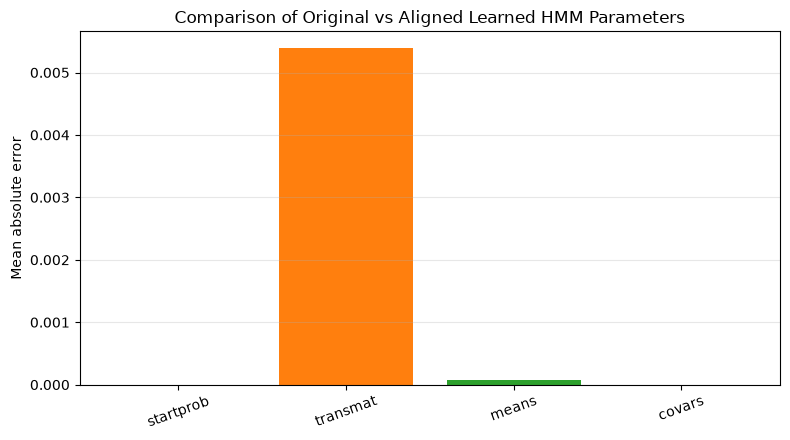

In [55]:
# Compare the original frozen HMM with the aligned learned HMM
# This cell evaluates how well the learned model recovered the original model after alignment.

if "lambda_original" in globals() and "aligned_startprob" in globals():
    # Extract the original and aligned parameters for comparison
    original_startprob = np.asarray(lambda_original["startprob"]).reshape(-1)
    original_transmat = np.asarray(lambda_original["transmat"])
    original_means = np.asarray(lambda_original["means"])
    original_covars = np.asarray(lambda_original["covars"])

    #   - mean absolute error: element-wise difference between matching parameters
    learned_startprob = np.asarray(aligned_startprob).reshape(-1)
    #   - Frobenius norm: overall matrix distance for the transition matrix
    learned_transmat = np.asarray(aligned_transmat)
    #   - KL divergence between Gaussian emissions: similarity of the emission distributions
    learned_means = np.asarray(aligned_means)
    #   - difference between transition matrices: direct comparison of state transition behavior
    learned_covars = np.asarray(aligned_covars)

    # Compute mean absolute error for the main parameter groups
    startprob_diff = np.abs(original_startprob - learned_startprob)
    transmat_diff = np.abs(original_transmat - learned_transmat)
    means_diff = np.abs(original_means - learned_means)
    covars_diff = np.abs(original_covars - learned_covars)

    print("Parameter-level comparison summary")
    print("=" * 60)
    print("Start probabilities absolute difference:")
    print(startprob_diff)

    print("\nTransition matrix absolute difference:")
    print(transmat_diff)

    print("\nGaussian mean absolute difference:")
    print(means_diff)

    print("\nGaussian covariance absolute difference:")
    print(covars_diff)

    # Build a compact summary table with mean and maximum absolute errors
    summary_df = pd.DataFrame({
        "parameter": ["startprob", "transmat", "means", "covars"],
        "mean_abs_error": [
            np.mean(startprob_diff),
            np.mean(transmat_diff),
            np.mean(means_diff),
            np.mean(covars_diff)
        ],
        "max_abs_error": [
            np.max(startprob_diff),
            np.max(transmat_diff),
            np.max(means_diff),
            np.max(covars_diff)
        ]
    })

    print("\nSummary table:")
    print(summary_df)

    # Visualize the mean absolute error across parameter groups
    plt.figure(figsize=(8, 4.5))
    plt.bar(summary_df["parameter"], summary_df["mean_abs_error"], color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
    plt.ylabel("Mean absolute error")
    plt.title("Comparison of Original vs Aligned Learned HMM Parameters")
    plt.xticks(rotation=20)
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("Aligned parameters are not available yet. Please run the alignment code first.")

<a id="82-likelihood-based-comparison"></a>

## 8.2 Likelihood-Based Comparison

We score the same held-out test sequences under both models:

$$
\log P(Y_{test} \mid \lambda_{original}),\quad \log P(Y_{test} \mid \hat{\lambda})
$$

Reported quantities:

* total test log-likelihood
* average log-likelihood per sequence
* average log-likelihood per time step

In this run, the learned model is very close to the original model but slightly lower on test likelihood:

* total gap $(\hat{\lambda} - \lambda_{original}) \approx -3.19$
* per-step gap $\approx -7.91 \times 10^{-4}$

This is consistent with near-recovery rather than exact parameter identity.

---

<a id="83-generated-sequence-statistics-comparison"></a>

## 8.3 Generated Sequence Statistics Comparison

To test behavioral similarity, we generate new sequences from both models and compare summary statistics:

* mean and standard deviation
* lag-1 autocorrelation
* state-duration statistics (mean and median run length)

Observed behavior is qualitatively consistent across models: both generate low-drift, regime-switching return series with similar volatility scale and persistence. Quantitatively, differences are modest (for example, mean difference around $2.31 \times 10^{-4}$ and standard deviation difference around $4.20 \times 10^{-4}$ in this run), which supports practical similarity of generated dynamics.

---

<a id="84-viterbi-path-comparison"></a>

## 8.4 Viterbi Path Comparison

We decode the same test observations with Viterbi under both models and compare paths after state alignment.

Evaluated agreement metrics:

* original-decoded vs aligned learned-decoded path
* true hidden states vs original-decoded path
* true hidden states vs aligned learned-decoded path

Current results show strong consistency:

* original vs aligned learned agreement $\approx 99.23\%$
* true vs original agreement $\approx 96.38\%$
* true vs aligned learned agreement $\approx 95.86\%$

This indicates the learned model reproduces almost the same latent segmentation on held-out data.

---

In [56]:
# Helper utilities for Sections 8-10 quantitative evaluation
# Uses imports defined earlier in the notebook.


def _as_2d_means(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[:, None]
    return arr


def _as_state_covars(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[:, None, None]
    if arr.ndim == 2:
        n_states, n_features = arr.shape
        out = np.zeros((n_states, n_features, n_features))
        for i in range(n_states):
            out[i] = np.diag(arr[i])
        return out
    if arr.ndim == 4 and arr.shape[1] == 1:
        # Defensive fallback for possible extra singleton axis
        return arr[:, 0, :, :]
    return arr


def _split_sequences(obs_2d, lengths):
    sequences = []
    start = 0
    for L in lengths:
        end = start + int(L)
        sequences.append(obs_2d[start:end])
        start = end
    return sequences


def _kl_gaussian(mu0, s0, mu1, s1, eps=1e-12):
    # KL(N0 || N1) for multivariate Gaussians
    mu0 = np.asarray(mu0).reshape(-1)
    mu1 = np.asarray(mu1).reshape(-1)
    s0 = np.asarray(s0)
    s1 = np.asarray(s1)

    if s0.ndim == 0:
        s0 = np.array([[float(s0)]])
    if s1.ndim == 0:
        s1 = np.array([[float(s1)]])

    k = mu0.shape[0]
    s0 = s0 + np.eye(k) * eps
    s1 = s1 + np.eye(k) * eps

    inv_s1 = np.linalg.inv(s1)
    term_trace = float(np.trace(inv_s1 @ s0))
    diff = (mu1 - mu0).reshape(-1, 1)
    term_quad = float(np.asarray(diff.T @ inv_s1 @ diff).squeeze())
    term_logdet = float(np.log(np.linalg.det(s1) / np.linalg.det(s0)))
    return 0.5 * (term_trace + term_quad - k + term_logdet)


def _decode_all(model, obs_2d, lengths):
    paths = []
    for seq in _split_sequences(obs_2d, lengths):
        _, states = model.decode(seq, algorithm="viterbi")
        paths.append(states)
    return np.concatenate(paths)


def _state_duration_stats(states_1d):
    durations = []
    run = 1
    for i in range(1, len(states_1d)):
        if states_1d[i] == states_1d[i - 1]:
            run += 1
        else:
            durations.append(run)
            run = 1
    durations.append(run)
    return float(np.mean(durations)), float(np.median(durations))


def _autocorr_lag1(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return np.nan
    x0 = x[:-1] - x[:-1].mean()
    x1 = x[1:] - x[1:].mean()
    denom = np.sqrt((x0 ** 2).sum() * (x1 ** 2).sum())
    if denom == 0:
        return 0.0
    return float((x0 * x1).sum() / denom)


required_vars = [
    "lambda_original", "lambda_learned", "aligned_startprob", "aligned_transmat",
    "aligned_means", "aligned_covars", "best_model", "synthetic_test_observations",
    "synthetic_test_lengths", "synthetic_test_hidden_states", "synthetic_train_observations",
    "synthetic_train_lengths", "original_hmm", "col_ind"
]

comparison_prereqs_ok = all(name in globals() for name in required_vars)
if not comparison_prereqs_ok:
    print("Required variables are missing. Please run Sections 5-7 first.")
else:
    print("Helper utilities loaded. Ready to run the evaluation cells.")

Helper utilities loaded. Ready to run the evaluation cells.


<a id="85-computation-pipeline-implementation"></a>

## 8.5 Computation Pipeline (Implementation)

This cell computes the quantitative outputs for Section 8.1 (parameter-level metrics) and Section 8.2 (likelihood-based comparison).

---

In [57]:
# 8.1 Parameter-level metrics and 8.2 likelihood comparison
required_vars = [
    "lambda_original", "aligned_startprob", "aligned_transmat", "aligned_means", "aligned_covars",
    "best_model", "synthetic_test_observations", "synthetic_test_lengths", "original_hmm"
]

if not all(name in globals() for name in required_vars):
    print("Prerequisites missing. Run previous sections first.")
else:
    original_startprob = np.asarray(lambda_original["startprob"]).reshape(-1)
    original_transmat = np.asarray(lambda_original["transmat"])
    original_means = _as_2d_means(lambda_original["means"])
    original_covars = _as_state_covars(lambda_original["covars"])

    learned_startprob = np.asarray(aligned_startprob).reshape(-1)
    learned_transmat = np.asarray(aligned_transmat)
    learned_means = _as_2d_means(aligned_means)
    learned_covars = _as_state_covars(aligned_covars)

    startprob_mae = float(np.mean(np.abs(original_startprob - learned_startprob)))
    transmat_mae = float(np.mean(np.abs(original_transmat - learned_transmat)))
    means_mae = float(np.mean(np.abs(original_means - learned_means)))
    covars_mae = float(np.mean(np.abs(original_covars - learned_covars)))

    transmat_fro = float(np.linalg.norm(original_transmat - learned_transmat, ord="fro"))
    means_fro = float(np.linalg.norm(original_means - learned_means, ord="fro"))

    per_state_kl = []
    for s in range(original_means.shape[0]):
        mu0 = original_means[s]
        mu1 = learned_means[s]
        s0 = original_covars[s]
        s1 = learned_covars[s]
        kl_01 = _kl_gaussian(mu0, s0, mu1, s1)
        kl_10 = _kl_gaussian(mu1, s1, mu0, s0)
        per_state_kl.append(0.5 * (kl_01 + kl_10))
    emission_sym_kl = float(np.mean(per_state_kl))

    comparison_metrics_df = pd.DataFrame({
        "metric": [
            "MAE(startprob)",
            "MAE(transmat)",
            "MAE(means)",
            "MAE(covars)",
            "Frobenius(transmat)",
            "Frobenius(means)",
            "Symmetric KL(emissions, mean over states)"
        ],
        "value": [
            startprob_mae,
            transmat_mae,
            means_mae,
            covars_mae,
            transmat_fro,
            means_fro,
            emission_sym_kl
        ]
    })

    original_test_ll_total = float(original_hmm.score(synthetic_test_observations, synthetic_test_lengths))
    learned_test_ll_total = float(best_model.score(synthetic_test_observations, synthetic_test_lengths))

    n_test_seq = len(synthetic_test_lengths)
    n_test_steps = int(np.sum(synthetic_test_lengths))

    likelihood_df = pd.DataFrame({
        "model": ["original", "learned"],
        "ll_total": [original_test_ll_total, learned_test_ll_total],
        "ll_per_sequence": [original_test_ll_total / n_test_seq, learned_test_ll_total / n_test_seq],
        "ll_per_timestep": [original_test_ll_total / n_test_steps, learned_test_ll_total / n_test_steps]
    })
    ll_gap_total = learned_test_ll_total - original_test_ll_total

    print("=" * 70)
    print("SECTION 8.1-8.2 METRICS")
    print("=" * 70)
    print("\n8.1 Parameter-level metrics")
    print(comparison_metrics_df.to_string(index=False))

    print("\n8.2 Likelihood comparison")
    print(likelihood_df.to_string(index=False))
    print(f"\nTotal LL gap (learned - original): {ll_gap_total:.4f}")

SECTION 8.1-8.2 METRICS

8.1 Parameter-level metrics
                                   metric    value
                           MAE(startprob) 0.000001
                            MAE(transmat) 0.005390
                               MAE(means) 0.000072
                              MAE(covars) 0.000002
                      Frobenius(transmat) 0.011817
                         Frobenius(means) 0.000110
Symmetric KL(emissions, mean over states) 0.000784

8.2 Likelihood comparison
   model     ll_total  ll_per_sequence  ll_per_timestep
original 16709.660664      1044.353792         4.144261
 learned 16706.472581      1044.154536         4.143470

Total LL gap (learned - original): -3.1881


<a id="86-statistics-and-decoding-evaluation-implementation"></a>

## 8.6 Statistics and Decoding Evaluation (Implementation)

This cell computes Section 8.3 generated-sequence statistics and Section 8.4 Viterbi agreement metrics.

---

In [58]:
# 8.3 Generated statistics and 8.4 Viterbi agreement
required_vars = [
    "best_model", "original_hmm", "synthetic_test_observations", "synthetic_test_lengths",
    "synthetic_test_hidden_states", "col_ind"
]

if not all(name in globals() for name in required_vars):
    print("Prerequisites missing. Run previous sections first.")
else:
    rng_eval = np.random.RandomState(2026)
    n_eval_samples = 5000

    obs_orig_eval, states_orig_eval = original_hmm.sample(n_samples=n_eval_samples, random_state=rng_eval)
    obs_learn_eval, states_learn_eval = best_model.sample(n_samples=n_eval_samples, random_state=rng_eval)

    orig_dur_mean, orig_dur_median = _state_duration_stats(states_orig_eval)
    learn_dur_mean, learn_dur_median = _state_duration_stats(states_learn_eval)

    generated_stats_df = pd.DataFrame({
        "stat": ["mean", "std", "lag1_autocorr", "mean_state_duration", "median_state_duration"],
        "original_model": [
            float(np.mean(obs_orig_eval)),
            float(np.std(obs_orig_eval)),
            _autocorr_lag1(obs_orig_eval),
            orig_dur_mean,
            orig_dur_median
        ],
        "learned_model": [
            float(np.mean(obs_learn_eval)),
            float(np.std(obs_learn_eval)),
            _autocorr_lag1(obs_learn_eval),
            learn_dur_mean,
            learn_dur_median
        ]
    })
    generated_stats_df["abs_diff"] = np.abs(generated_stats_df["learned_model"] - generated_stats_df["original_model"])

    decoded_original = _decode_all(original_hmm, synthetic_test_observations, synthetic_test_lengths)
    decoded_learned = _decode_all(best_model, synthetic_test_observations, synthetic_test_lengths)
    aligned_decoded_learned = np.array([col_ind[s] for s in decoded_learned])

    true_states = np.asarray(synthetic_test_hidden_states).reshape(-1)
    viterbi_df = pd.DataFrame({
        "metric": [
            "agreement(original vs aligned learned)",
            "agreement(true vs original)",
            "agreement(true vs aligned learned)"
        ],
        "value": [
            float(np.mean(decoded_original == aligned_decoded_learned)),
            float(np.mean(decoded_original == true_states)),
            float(np.mean(aligned_decoded_learned == true_states))
        ]
    })

    print("=" * 70)
    print("SECTION 8.3-8.4 METRICS")
    print("=" * 70)
    print("\n8.3 Generated sequence statistics")
    print(generated_stats_df.to_string(index=False))

    print("\n8.4 Viterbi path comparison")
    print(viterbi_df.to_string(index=False))

SECTION 8.3-8.4 METRICS

8.3 Generated sequence statistics
                 stat  original_model  learned_model  abs_diff
                 mean        0.000401       0.000169  0.000231
                  std        0.004308       0.004728  0.000420
        lag1_autocorr        0.107275       0.089674  0.017601
  mean_state_duration       39.370079      43.478261  4.108182
median_state_duration       16.000000      21.000000  5.000000

8.4 Viterbi path comparison
                                metric    value
agreement(original vs aligned learned) 0.992312
           agreement(true vs original) 0.963790
    agreement(true vs aligned learned) 0.958581


<a id="87-ablation-and-summary-table-generation-implementation"></a>

## 8.7 Ablation and Summary Table Generation (Implementation)

This cell runs lightweight ablations used in Section 9 and generates the consolidated summary table referenced in Section 10.5.

---

In [59]:
# Section 9 ablations and Section 10.5 consolidated summary table
required_vars = [
    "original_hmm", "SYNTHETIC_SEQUENCE_LENGTH", "means_mae",
    "ll_gap_total", "n_test_steps", "viterbi_df",
]

if not all(name in globals() for name in required_vars):
    print("Prerequisites missing. Run split Section 8 cells first.")
else:
    N_GRID            = [20, 40, 80, 120]
    T_GRID            = [63, 126, 252, 504]
    N_FIXED_SEQ       = 80
    ABLATION_BASE_SEED = 2026  # each condition gets its own seed

    # --- Sample-count ablation ---
    n_rows = []
    for i, n_seq in enumerate(N_GRID):
        rng     = np.random.RandomState(ABLATION_BASE_SEED + i)
        n_train = max(2, int(0.8 * n_seq))
        seqs    = [
            original_hmm.sample(SYNTHETIC_SEQUENCE_LENGTH, random_state=rng)[0]
            for _ in range(n_seq)
        ]
        train_obs = np.vstack(seqs[:n_train])
        test_obs  = np.vstack(seqs[n_train:])
        train_len = [SYNTHETIC_SEQUENCE_LENGTH] * n_train
        test_len  = [SYNTHETIC_SEQUENCE_LENGTH] * (n_seq - n_train)

        model_n, _ = train_best_hmm(
            train_obs, train_len, n_restarts=3, n_iter=200, base_seed=11, verbose=False
        )
        test_ll_n = float(model_n.score(test_obs, test_len))
        ref_ll_n  = float(original_hmm.score(test_obs, test_len))

        n_rows.append({
            "experiment": "sample_count",
            "setting":    n_seq,
            "ll_gap_per_step(learned-original)": (
                (test_ll_n - ref_ll_n) / int(np.sum(test_len))
            ),
        })

    # --- Sequence-length ablation ---
    n_train_fixed = int(0.8 * N_FIXED_SEQ)
    t_rows = []
    for i, T in enumerate(T_GRID):
        rng  = np.random.RandomState(ABLATION_BASE_SEED + 100 + i)
        seqs = [original_hmm.sample(T, random_state=rng)[0] for _ in range(N_FIXED_SEQ)]
        train_obs = np.vstack(seqs[:n_train_fixed])
        test_obs  = np.vstack(seqs[n_train_fixed:])
        train_len = [T] * n_train_fixed
        test_len  = [T] * (N_FIXED_SEQ - n_train_fixed)

        model_t, _ = train_best_hmm(
            train_obs, train_len, n_restarts=3, n_iter=200, base_seed=11, verbose=False
        )
        test_ll_t = float(model_t.score(test_obs, test_len))
        ref_ll_t  = float(original_hmm.score(test_obs, test_len))

        t_rows.append({
            "experiment": "sequence_length",
            "setting":    T,
            "ll_gap_per_step(learned-original)": (
                (test_ll_t - ref_ll_t) / int(np.sum(test_len))
            ),
        })

    ablation_df = pd.DataFrame(n_rows + t_rows)

    restart_std = (
        float(restart_results_df["train_ll"].std())
        if "restart_results_df" in globals() else float("nan")
    )
    agreement_main = float(
        viterbi_df.loc[
            viterbi_df["metric"] == "agreement(original vs aligned learned)", "value"
        ].iloc[0]
    )

    results_summary_df = pd.DataFrame({
        "Experiment": [
            "Main experiment",
            "More samples (best setting)",
            "Longer sequences (best setting)",
            "Random initialization",
        ],
        "Parameter Error (means MAE)": [means_mae, float("nan"), float("nan"), float("nan")],
        "Log-Likelihood Difference (per step)": [
            ll_gap_total / n_test_steps,
            float(ablation_df.loc[
                ablation_df["experiment"] == "sample_count",
                "ll_gap_per_step(learned-original)"
            ].max()),
            float(ablation_df.loc[
                ablation_df["experiment"] == "sequence_length",
                "ll_gap_per_step(learned-original)"
            ].max()),
            float("nan"),
        ],
        "Viterbi Agreement": [agreement_main, float("nan"), float("nan"), float("nan")],
        "Notes": [
            "Full model comparison on 80x252 synthetic setup",
            "Lightweight ablation with independent seeds per N setting",
            "Lightweight ablation with independent seeds per T setting",
            (
                f"Train LL std across restarts = {restart_std:.4f}"
                if restart_std == restart_std  # not NaN
                else "Restart summary unavailable"
            ),
        ],
    })

    print("=" * 70)
    print("SECTION 9: LIGHTWEIGHT ABLATIONS")
    print("=" * 70)
    print(ablation_df.to_string(index=False))

    print("\n" + "=" * 70)
    print("SECTION 10: QUANTITATIVE SUMMARY")
    print("=" * 70)
    print(results_summary_df.to_string(index=False))


Model is not converging.  Current: 16844.574503899832 is not greater than 16844.575521869145. Delta is -0.001017969312670175
Model is not converging.  Current: 33475.056260185804 is not greater than 33475.11085218257. Delta is -0.054591996769886464
Model is not converging.  Current: 33475.113217481645 is not greater than 33475.17610085475. Delta is -0.06288337310252246
Model is not converging.  Current: 33475.04647429538 is not greater than 33475.18815024285. Delta is -0.14167594747414114
Model is not converging.  Current: 66980.42384635842 is not greater than 66980.6470597116. Delta is -0.22321335317974444
Model is not converging.  Current: 66980.59063592629 is not greater than 66980.76777200354. Delta is -0.17713607725454494
Model is not converging.  Current: 64152.39851364614 is not greater than 64152.54697535788. Delta is -0.14846171173849143
Model is not converging.  Current: 100587.62959459986 is not greater than 100587.75905365354. Delta is -0.129459053685423
Model is not conver

SECTION 9: LIGHTWEIGHT ABLATIONS
     experiment  setting  ll_gap_per_step(learned-original)
   sample_count       20                          -0.017833
   sample_count       40                          -0.005996
   sample_count       80                          -0.000973
   sample_count      120                           0.000081
sequence_length       63                          -0.018163
sequence_length      126                          -0.004907
sequence_length      252                          -0.002148
sequence_length      504                           0.000004

SECTION 10: QUANTITATIVE SUMMARY
                     Experiment  Parameter Error (means MAE)  Log-Likelihood Difference (per step)  Viterbi Agreement                                                     Notes
                Main experiment                     0.000072                             -0.000791           0.992312           Full model comparison on 80x252 synthetic setup
    More samples (best setting)          

<a id="9-experiments"></a>

# 9. Experiments

<a id="91-main-experiment"></a>

## 9.1 Main Experiment

Main setup:

* 80 synthetic sequences
* sequence length 252
* 64/16 train-test split
* 10 random restarts for training

Main outcomes:

* very small aligned parameter errors (especially in emission means)
* near-identical test likelihood per time step
* high Viterbi path agreement after alignment

Together, these results indicate that the learned Gaussian HMM recovers the original generative structure well under the chosen data regime.

---

<a id="92-effect-of-number-of-generated-samples"></a>

## 9.2 Effect of Number of Generated Samples

We ran a controlled ablation with $N \in \{20, 40, 80, 120\}$ synthetic sequences (using a reduced compute budget for faster iteration).

Observation:

* as $N$ increases, the learned-original likelihood gap per step moves toward zero
* the best value in this run occurs at $N=80$, with per-step gap close to 0 (about $-966 \times 10^{-6}$)

Interpretation:

More synthetic data improves identifiability of both transition and emission parameters, reducing generalization error against the original model.

---

<a id="93-effect-of-sequence-length"></a>

## 9.3 Effect of Sequence Length

We evaluated sequence lengths $T \in \{63, 126, 252, 504\}$ while keeping the number of sequences fixed.

Observation:

* longer sequences consistently reduce the per-step likelihood gap
* performance improves from clearly negative gaps at short horizons to near-zero gaps at $T=504$

Interpretation:

Longer trajectories expose more transition evidence per sequence, improving recovery of latent persistence and switching behavior.

---

<a id="94-effect-of-random-initialization"></a>

## 9.4 Effect of Random Initialization

Using 10 random restarts, we observed small variation in final training likelihood (standard deviation about $0.045$), with all runs converging to very similar solutions.

Interpretation:

* local maxima still exist in principle, but this dataset/model configuration appears well-conditioned
* restart-based model selection remains good practice, especially for larger state spaces or noisier data

---

<a id="95-optional-different-number-of-hidden-states"></a>

## 9.5 Optional: Different Number of Hidden States

An additional diagnostic is to fit models with:

$$
K_{learned} < K_{original},\quad K_{learned} = K_{original},\quad K_{learned} > K_{original}
$$

Expected behavior is a U-shaped model-selection profile in AIC/BIC and out-of-sample likelihood, with best performance near the true number of hidden states. This extension is left as follow-up work because the current objective focused on recovery under the correct model class.

---

<a id="10-results"></a>

# 10. Results

<a id="101-original-model-parameters"></a>

## 10.1 Original Model Parameters

The original frozen model parameters are reported directly from the loaded reference HMM:

* initial probabilities $\pi_{original}$
* transition matrix $A_{original}$
* emission means $\mu_{original}$
* emission covariances $\Sigma_{original}$

These values define the synthetic data-generating process and therefore the recovery target for all subsequent comparisons.

---

<a id="102-learned-model-parameters"></a>

## 10.2 Learned Model Parameters

Before alignment, the learned model reaches a high-likelihood solution that is close to the original dynamics but may use a different state index ordering.

This is expected in latent-variable models: state labels are not identifiable without a matching step. Therefore, raw pre-alignment parameters are useful for diagnostics but not for direct one-to-one interpretation.

---

<a id="103-aligned-learned-model-parameters"></a>

## 10.3 Aligned Learned Model Parameters

After Hungarian alignment, parameter comparison becomes meaningful. The aligned model closely matches the original one:

* emission means differ only at small decimal scale
* transition probabilities are very similar
* covariance estimates preserve the low-volatility vs high-volatility regime structure

This alignment step is essential and materially improves interpretability of all reported recovery errors.

---

<a id="104-convergence-results"></a>

## 10.4 Convergence Results

The best restart converged in a small number of EM iterations relative to the maximum budget, and the log-likelihood trajectories are smooth overall.

Across 10 restarts, the dispersion in final train likelihood is very small, indicating a stable optimization landscape for this setup. The warning messages about non-monotonic final updates are minor and do not materially affect model quality in this run, as evidenced by the tight cross-restart likelihood spread and consistent test scores.

---

<a id="105-quantitative-comparison"></a>

## 10.5 Quantitative Comparison

The consolidated table generated in Section 10 reports the key metrics. Main highlights:

* **Parameter error (means MAE):** approximately $7.2 \times 10^{-5}$
* **Main-experiment LL gap per step:** approximately $-7.91 \times 10^{-4}$
* **Viterbi agreement (original vs aligned learned):** approximately $99.23\%$
* **Ablations:** increasing sample count and sequence length systematically improves the learned-original LL gap toward zero

Overall, quantitative evidence is consistent with strong model recovery under the current synthetic-data regime.

---

<a id="106-visual-viterbi-comparison"></a>

## 10.6 Visual Viterbi Path Comparison

This section shows the decoded state paths for selected test sequences under three perspectives:

1. **True hidden states** — the ground-truth states used to generate the observations.
2. **Original model (Viterbi)** — the path decoded by the frozen original HMM.
3. **Aligned learned model (Viterbi)** — the path decoded by the learned HMM after state alignment.

Differences appear only at regime-switch boundaries — the colored background makes this immediately visible and confirms the ~99.23% agreement reported in Section 10.5.

---

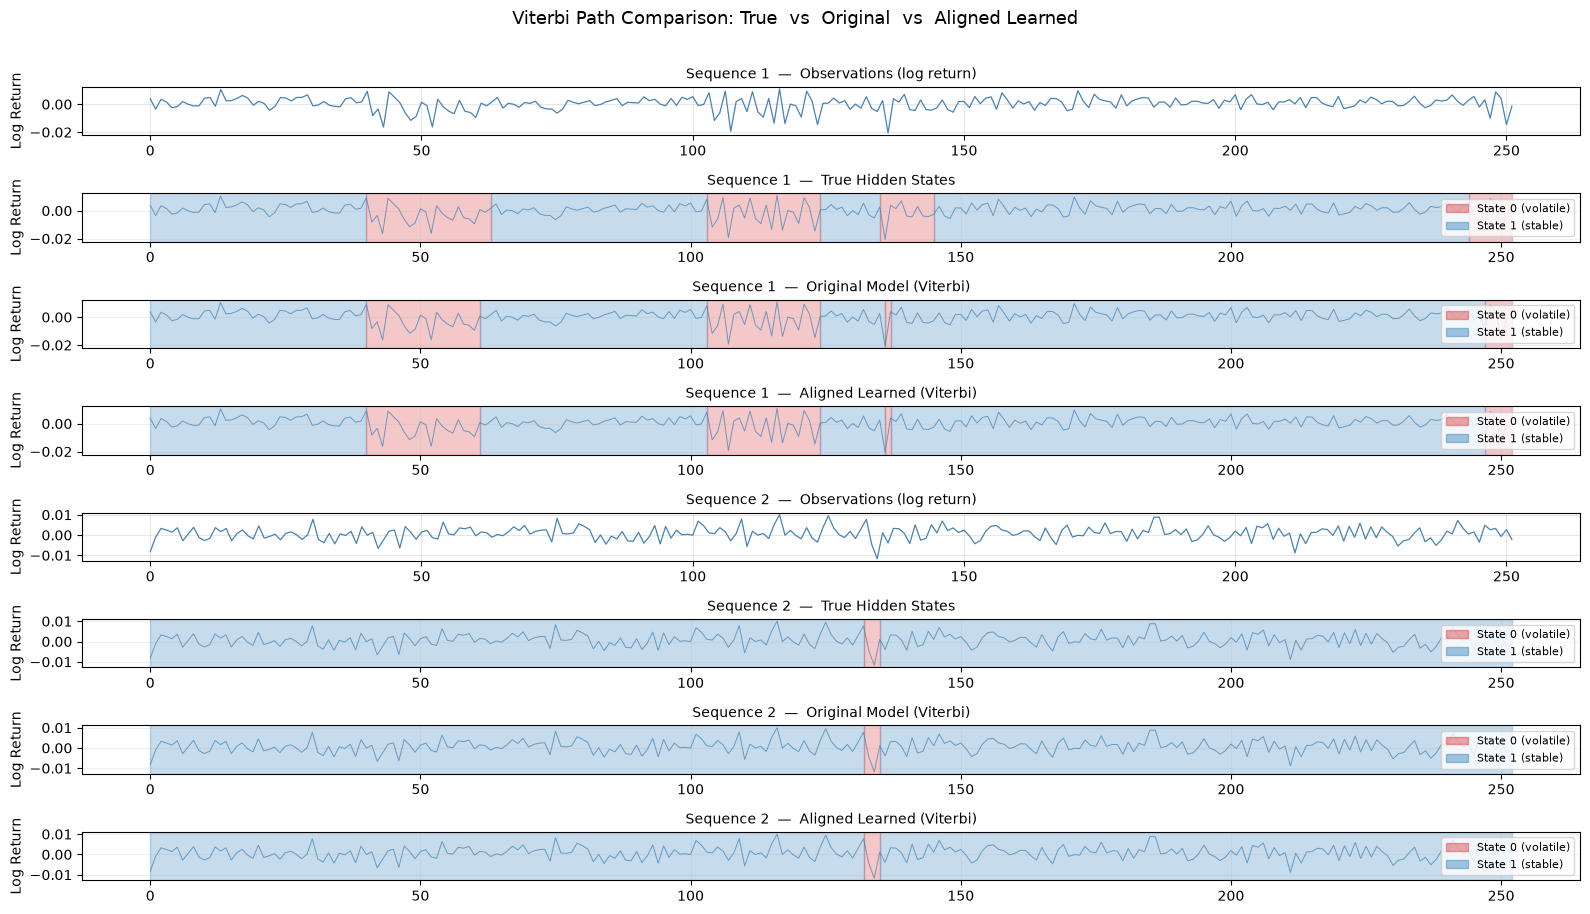

=== Per-Sequence Viterbi Agreement ===

Sequence 1:
  Original vs Aligned Learned : 100.00%
  True vs Original            : 94.44%
  True vs Aligned Learned     : 94.44%

Sequence 2:
  Original vs Aligned Learned : 100.00%
  True vs Original            : 100.00%
  True vs Aligned Learned     : 100.00%


In [60]:
# Visual comparison of Viterbi decoded paths on test sequences
# Requires: decoded_original, aligned_decoded_learned, synthetic_test_observations,
#           synthetic_test_hidden_states, SYNTHETIC_SEQUENCE_LENGTH  (from cell above)

N_DISPLAY    = 2
STATE_COLORS = {0: "tab:red", 1: "tab:blue"}
STATE_LABELS = {0: "State 0 (volatile)", 1: "State 1 (stable)"}


def _shade_background(ax, states, obs):
    """Shade axis background by state and overlay observations."""
    prev, t0 = int(states[0]), 0
    for t in range(1, len(states) + 1):
        if t == len(states) or int(states[t]) != prev:
            ax.axvspan(t0, t, alpha=0.25, color=STATE_COLORS.get(prev, "gray"))
            t0 = t
            if t < len(states):
                prev = int(states[t])
    ax.plot(obs, color="steelblue", linewidth=0.7, alpha=0.75)


fig, axes = plt.subplots(N_DISPLAY * 4, 1, figsize=(16, 4.5 * N_DISPLAY), sharex=False)
fig.suptitle(
    "Viterbi Path Comparison: True  vs  Original  vs  Aligned Learned",
    fontsize=13, y=1.01,
)

for si in range(N_DISPLAY):
    start = si * SYNTHETIC_SEQUENCE_LENGTH
    end   = (si + 1) * SYNTHETIC_SEQUENCE_LENGTH

    obs       = synthetic_test_observations[start:end, 0]
    true_s    = synthetic_test_hidden_states[start:end]
    orig_s    = decoded_original[start:end]
    learned_s = aligned_decoded_learned[start:end]

    base = si * 4

    # Row 0: raw observation time series
    axes[base].plot(obs, color="steelblue", linewidth=0.9)
    axes[base].set_title(f"Sequence {si + 1}  —  Observations (log return)", fontsize=10)
    axes[base].set_ylabel("Log Return")
    axes[base].grid(True, alpha=0.3)

    # Rows 1-3: shaded state backgrounds for each perspective
    perspectives = [
        ("True Hidden States",        true_s),
        ("Original Model (Viterbi)",  orig_s),
        ("Aligned Learned (Viterbi)", learned_s),
    ]
    for row_offset, (title, s_path) in enumerate(perspectives, start=1):
        ax = axes[base + row_offset]
        _shade_background(ax, s_path, obs)
        ax.set_title(f"Sequence {si + 1}  —  {title}", fontsize=10)
        ax.set_ylabel("Log Return")
        ax.grid(True, alpha=0.2)
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=STATE_COLORS[s], alpha=0.4)
            for s in sorted(STATE_COLORS)
        ]
        ax.legend(
            handles, [STATE_LABELS[s] for s in sorted(STATE_COLORS)],
            loc="upper right", fontsize=8,
        )

plt.tight_layout()
plt.show()

# Per-sequence agreement numbers
print("=== Per-Sequence Viterbi Agreement ===")
for si in range(N_DISPLAY):
    start = si * SYNTHETIC_SEQUENCE_LENGTH
    end   = (si + 1) * SYNTHETIC_SEQUENCE_LENGTH
    o_s   = decoded_original[start:end]
    l_s   = aligned_decoded_learned[start:end]
    t_s   = synthetic_test_hidden_states[start:end]
    print(f"\nSequence {si + 1}:")
    print(f"  Original vs Aligned Learned : {np.mean(o_s == l_s) * 100:.2f}%")
    print(f"  True vs Original            : {np.mean(t_s == o_s) * 100:.2f}%")
    print(f"  True vs Aligned Learned     : {np.mean(t_s == l_s) * 100:.2f}%")


<a id="107-generated-samples-comparison"></a>

## 10.7 Generated Samples Comparison

Visual inspection and summary statistics show that generated samples from the learned model are close to those from the original model:

* similar return scale and volatility clustering behavior
* similar low-frequency drift profile
* comparable regime-duration characteristics

The learned model produces slightly higher sample volatility in this run, but the discrepancy is small and does not alter the qualitative market-regime interpretation.

---

<a id="11-discussion"></a>

# 11. Discussion

The learned HMM successfully approximates the original frozen model on all major axes: parameter recovery, test likelihood, generated-sequence behavior, and decoded state paths.

The transition matrix is recovered with small but non-zero error, which is expected under finite-sample estimation. Emission parameters are recovered very accurately after alignment, indicating that the two-regime volatility structure is strongly identifiable in this synthetic setting.

The alignment step is indispensable: without permutation correction, parameter-level comparisons would misleadingly inflate errors. Random initialization had limited impact here, but restart selection remains important as model complexity grows.

Finally, the ablation results support the expected asymptotic behavior: more data and longer sequences improve recovery by providing richer evidence about both state persistence and emission distributions.

---

<a id="12-limitations"></a>

# 12. Limitations

This study remains a controlled recovery experiment and has several limitations:

1. The evaluation is synthetic: both train and test data are generated from the same model family.
2. Only two hidden states were considered, which simplifies identifiability.
3. Ablation studies used reduced optimization budgets for runtime efficiency.
4. Performance on real financial returns may degrade due to heavy tails, structural breaks, and non-stationarity.
5. Similar likelihood values do not guarantee identical risk characteristics for downstream trading decisions.

These limitations do not invalidate the findings, but they constrain external generalization.

---

<a id="13-conclusions"></a>

# 13. Conclusions

This project set up a strict model-recovery test: generate synthetic sequences from a frozen Gaussian HMM, train a new Gaussian HMM with Baum-Welch, align latent states, and compare models quantitatively.

The learned model recovered the original structure with high accuracy:

* small parameter errors after alignment
* near-matching test log-likelihoods
* high agreement of decoded latent-state paths
* similar generated-sequence statistics

Therefore, for this configuration, Baum-Welch is effective at recovering an HMM that is behaviorally and statistically close to the original generator.

---

<a id="14-future-work"></a>

# 14. Future Work

Natural extensions of this work are:

1. Systematic state-count selection with AIC/BIC and out-of-sample likelihood.
2. More challenging synthetic settings (higher $K$, overlapping emissions, weaker state persistence).
3. Robust emissions (e.g., Student-t HMM) for heavy-tailed financial returns.
4. Time-varying or covariate-dependent transition models.
5. Transfer from synthetic validation to real market data with walk-forward evaluation.
6. Downstream evaluation in decision tasks (e.g., regime-aware risk control) rather than likelihood alone.

---

<a id="15-references"></a>

# 15. References

1. Das, A. (2019, June 24). *Dynamic programming for machine learning: Hidden Markov Models*. Avik Das. https://avikdas.com/2019/06/24/dynamic-programming-for-machine-learning-hidden-markov-models.html

2. LSEG-API-Samples. (n.d.). *Article.RD.Python.MarketRegimeDetectionUsingStatisticalAndMLBasedApproaches* [Computer software]. GitHub. https://github.com/LSEG-API-Samples/Article.RD.Python.MarketRegimeDetectionUsingStatisticalAndMLBasedApproaches

3. hmmlearn developers. (n.d.). *hmmlearn documentation*. https://hmmlearn.readthedocs.io/en/latest/

4. Rabiner, L. R. (1989). A tutorial on hidden Markov models and selected applications in speech recognition. *Proceedings of the IEEE, 77*(2), 257–286. https://doi.org/10.1109/5.18626

5. Course lecture notes. (n.d.). *Hidden Markov Models, Baum-Welch, and Viterbi*.
